# 1. Import Libraries

In [95]:
!pip install --upgrade pip

In [96]:
!pip install -q xgboost catboost lightgbm shap

In [97]:
import os
import h5py
import time
import matplotlib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec

warnings.filterwarnings("ignore")

# Scikit-learn components for context processing and evaluation.
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Gradient boosting regressor for RUL prediction.
from xgboost import XGBRegressor

# Explainability toolkit for tree-based models.
import shap

# Reproducibility and experiment configuration.
SEED = 42
WINDOW_SIZE = 20
N_CLUSTERS = 3
OUTLIER_CONTAMINATION = 0.02
np.random.seed(SEED)

# Resolve dataset path for both Kaggle and local Windows usage.
DATASET_CANDIDATES = [
    os.environ.get("NCMAPSS_FILE", ""),
    "/kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS01-005.h5",
    "N-CMAPSS_DS01-005.h5",
    "./N-CMAPSS_DS01-005.h5",
    "./data/N-CMAPSS_DS01-005.h5",
    "./dataset/N-CMAPSS_DS01-005.h5",
]

filename = next((p for p in DATASET_CANDIDATES if p and os.path.exists(p)), None)
if filename is None:
    raise FileNotFoundError(
        "Khong tim thay file N-CMAPSS_DS01-005.h5. "
        "Hay dat bien moi truong NCMAPSS_FILE hoac dat file trong thu muc hien tai/data/dataset."
    )
print(f"[Data] Using file: {filename}")

[Data] Using file: /kaggle/input/datasets/bishals098/nasa-cmapss-2-engine-degradation/N-CMAPSS_DS01-005.h5


# 2. Dataset Exploration - N-CMAPSS DS02

The new C-MAPSS dataset DS02 from NASA provides degradation trajectories of 9 turbofan engines with unknown and different initial health condition for complete flights and two failure modes (HPT efficiency degradation & HPT efficiency degradation combined with LPT efficiency and capacity degradation). The data were synthetically generated with the Commercial Modular Aero-Propulsion System Simulation (C-MAPSS) dynamical model. The data contains multivariate sensors readings of the complete run-to-failure trajectories. Therefore, the records stop at the cycle/time the engine failed. A total number of 6.5M time stamps are available.

Copyright (c) by Manuel Arias.

After completing this exploration, the notebook transitions to a structured Hybrid ML pipeline for RUL prediction.

#### Read Raw Data

In [98]:
# Time tracking, Operation time (min):  0.003
t = time.process_time()  

# Load data
with h5py.File(filename, 'r') as hdf:
        # Development set
        W_dev = np.array(hdf.get('W_dev'))             # W
        X_s_dev = np.array(hdf.get('X_s_dev'))         # X_s
        X_v_dev = np.array(hdf.get('X_v_dev'))         # X_v
        T_dev = np.array(hdf.get('T_dev'))             # T
        Y_dev = np.array(hdf.get('Y_dev'))             # RUL  
        A_dev = np.array(hdf.get('A_dev'))             # Auxiliary

        # Test set
        W_test = np.array(hdf.get('W_test'))           # W
        X_s_test = np.array(hdf.get('X_s_test'))       # X_s
        X_v_test = np.array(hdf.get('X_v_test'))       # X_v
        T_test = np.array(hdf.get('T_test'))           # T
        Y_test = np.array(hdf.get('Y_test'))           # RUL  
        A_test = np.array(hdf.get('A_test'))           # Auxiliary
        
        # Varnams
        W_var = np.array(hdf.get('W_var'))
        X_s_var = np.array(hdf.get('X_s_var'))  
        X_v_var = np.array(hdf.get('X_v_var')) 
        T_var = np.array(hdf.get('T_var'))
        A_var = np.array(hdf.get('A_var'))
        
        # from np.array to list dtype U4/U5
        W_var = list(np.array(W_var, dtype='U20'))
        X_s_var = list(np.array(X_s_var, dtype='U20'))  
        X_v_var = list(np.array(X_v_var, dtype='U20')) 
        T_var = list(np.array(T_var, dtype='U20'))
        A_var = list(np.array(A_var, dtype='U20'))
                          
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))


Operation time (min):  0.04064602119997289

W shape: (7641868, 4)
X_s shape: (7641868, 14)
X_v shape: (7641868, 14)
T shape: (7641868, 10)
A shape: (7641868, 4)


## 2.1. Auxiliary Information ($A$)

In [99]:
df_A = DataFrame(data=A, columns=A_var)
df_A.describe()

,unit,cycle,Fc,hs
count,7.641868e+06,7.641868e+06,7.641868e+06,7.641868e+06
mean,5.562970e+00,4.452661e+01,2.252313e+00,2.688846e-01
std,2.869946e+00,2.593783e+01,7.779728e-01,4.433799e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.000000e+00,2.200000e+01,2.000000e+00,0.000000e+00
50%,5.000000e+00,4.400000e+01,2.000000e+00,0.000000e+00
75%,8.000000e+00,6.600000e+01,3.000000e+00,1.000000e+00
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00


###  Units Ids

In [100]:
print('Engine units in df: ', np.unique(df_A['unit']))

Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


### Flight Classes

The units are divided into three flight classes depending on whether the unit is operating short-length flights (i.e., flight class 1), medium-length flights (i.e., flight class 2), or long-length flights (i.e., flight class 2). A number of real flight conditions are available within each of the flight classes.

| Flight Class   | Flight Length [h]
| :-----------:  | :-----------:    
| 1              |    1 to 3        
| 2              |    3 to 5        
| 3              |    5 to 7        


Text(0, 0.5, 'Flight Class # [-]')

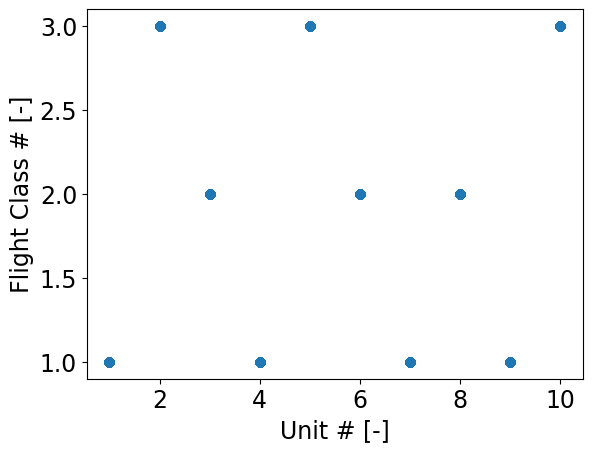

In [101]:
labelsize = 17
plt.plot(df_A.unit, df_A.Fc, 'o')
plt.tick_params(axis='x', labelsize=labelsize )
plt.tick_params(axis='y', labelsize=labelsize )
plt.xlabel('Unit # [-]', fontsize=labelsize)
plt.ylabel('Flight Class # [-]', fontsize=labelsize )

### End Of Failure ($t_{\text{EOF}}$)

The run to failure operation take a different number of cycles for each unit. Below we report the total number of cycles for each unit.

In [102]:
for i in np.unique(df_A['unit']):
    print('Unit: ' + str(i) + ' - Number of flight cyles (t_{EOF}): ', len(np.unique(df_A.loc[df_A['unit'] == i, 'cycle'])))
    #np.unique(df_A.loc[df_A['unit'] == i, 'cycle'])

Unit: 1.0 - Number of flight cyles (t_{EOF}):  100
Unit: 2.0 - Number of flight cyles (t_{EOF}):  75
Unit: 3.0 - Number of flight cyles (t_{EOF}):  100
Unit: 4.0 - Number of flight cyles (t_{EOF}):  95
Unit: 5.0 - Number of flight cyles (t_{EOF}):  89
Unit: 6.0 - Number of flight cyles (t_{EOF}):  94
Unit: 7.0 - Number of flight cyles (t_{EOF}):  90
Unit: 8.0 - Number of flight cyles (t_{EOF}):  89
Unit: 9.0 - Number of flight cyles (t_{EOF}):  80
Unit: 10.0 - Number of flight cyles (t_{EOF}):  82


## 2.2. Operative Conditions ($w$)

DASHlink- Flight Data For Tail 687.(2012). Retrieved on 2019-01-29 from https://c3.nasa.gov/dashlink/

In [103]:
df_W = DataFrame(data=W, columns=W_var)
df_W['unit'] = df_A['unit'].values

In [104]:
def plot_df_single_color(data, variables, labels, size=12, labelsize=17, name=None):
    """
    """
    plt.clf()        
    input_dim = len(variables)
    cols = min(np.floor(input_dim**0.5).astype(int),4)
    rows = (np.ceil(input_dim / cols)).astype(int)
    gs   = gridspec.GridSpec(rows, cols)    
    fig  = plt.figure(figsize=(size,max(size,rows*2))) 
    
    for n in range(input_dim):
        ax = fig.add_subplot(gs[n])
        ax.plot(data[variables[n]], marker='.', markerfacecolor='none', alpha = 0.7)
        ax.tick_params(axis='x', labelsize=labelsize)
        ax.tick_params(axis='y', labelsize=labelsize)
        plt.ylabel(labels[n], fontsize=labelsize)
        plt.xlabel('Time [s]', fontsize=labelsize)
    plt.tight_layout()
    if name is not None:
        plt.savefig(name, format='png', dpi=300)   
    plt.show()
    plt.close()

In [105]:
def plot_df_color_per_unit(
    data,
    variables,
    labels,
    size=7,
    labelsize=17,
    option='Time',
    name=None,
    max_points_per_unit=3000
):
    """Memory-safe multi-unit plotting with per-unit downsampling."""
    plt.clf()
    input_dim = len(variables)
    cols = min(np.floor(input_dim**0.5).astype(int), 4)
    rows = (np.ceil(input_dim / cols)).astype(int)
    gs = gridspec.GridSpec(rows, cols)
    leg = []
    fig = plt.figure(figsize=(size, max(size, rows * 2)))
    color_dic_unit = {
        'Unit 1': 'C0', 'Unit 2': 'C1', 'Unit 3': 'C2', 'Unit 4': 'C3', 'Unit 5': 'C4', 'Unit 6': 'C5',
        'Unit 7': 'C6', 'Unit 8': 'C7', 'Unit 9': 'C8', 'Unit 10': 'C9', 'Unit 11': 'C10',
        'Unit 12': 'C11', 'Unit 13': 'C12', 'Unit 14': 'C13', 'Unit 15': 'C14', 'Unit 16': 'C15',
        'Unit 17': 'C16', 'Unit 18': 'C17', 'Unit 19': 'C18', 'Unit 20': 'C19'
    }

    unit_sel = np.unique(data['unit'])
    for n in range(input_dim):
        ax = fig.add_subplot(gs[n])
        for j in unit_sel:
            data_unit = data.loc[data['unit'] == j]
            n_rows = len(data_unit)
            stride = max(1, int(np.ceil(n_rows / max_points_per_unit)))

            if option == 'cycle':
                time_s = data_unit['cycle'].to_numpy()[::stride]
                label_x = 'Time [cycle]'
            else:
                time_s = np.arange(n_rows)[::stride]
                label_x = 'Time [s]'

            y_vals = data_unit[variables[n]].to_numpy()[::stride]

            # Skip markers for long traces to avoid kernel memory spikes.
            if stride > 1:
                ax.plot(time_s, y_vals, '-', color=color_dic_unit.get('Unit ' + str(int(j)), 'C0'), alpha=0.75, linewidth=1.0)
            else:
                ax.plot(time_s, y_vals, '-o', color=color_dic_unit.get('Unit ' + str(int(j)), 'C0'), alpha=0.7, markersize=3)

            ax.tick_params(axis='x', labelsize=labelsize)
            ax.tick_params(axis='y', labelsize=labelsize)
            leg.append('Unit ' + str(int(j)))

        plt.ylabel(labels[n], fontsize=labelsize)
        plt.xlabel(label_x, fontsize=labelsize)
        ax.get_xaxis().set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
        )
        if n == 0:
            ax.get_yaxis().set_major_formatter(
                matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
            )

    unique_leg = list(dict.fromkeys(leg))
    plt.legend(unique_leg, loc='best', fontsize=labelsize - 2)
    plt.tight_layout()
    if name is not None:
        plt.savefig(name, format='png', dpi=200)
    plt.show()
    plt.close()

### Flight Traces

<Figure size 640x480 with 0 Axes>

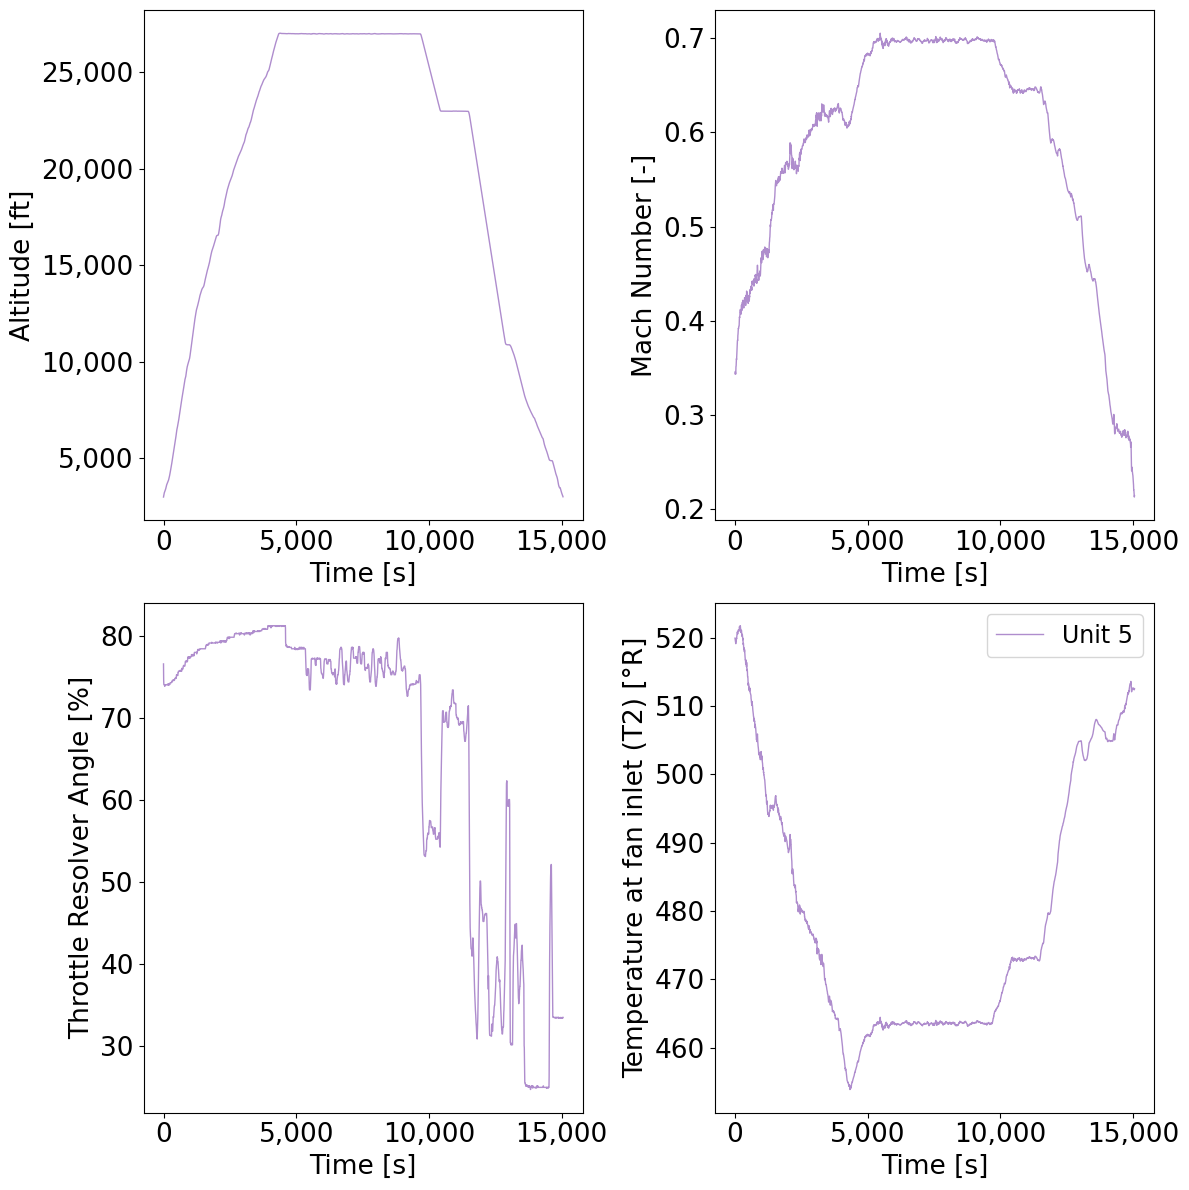

In [106]:
df_W_u = df_W.loc[(df_A.unit == 5) & (df_A.cycle == 1)]
df_W_u.reset_index(inplace=True, drop=True)
labels = ['Altitude [ft]', 'Mach Number [-]', 'Throttle Resolver Angle [%]', 'Temperature at fan inlet (T2) [°R]']
plot_df_color_per_unit(df_W_u, W_var , labels, size=12, labelsize=19, name='flight_profile_DS02.png')

### Flight envelope

Text(0, 0.5, 'Flight Altitude - [ft]')

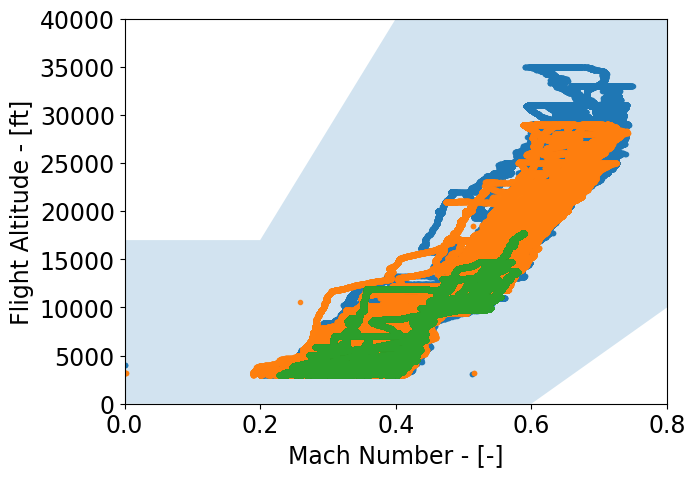

In [107]:
labelsize = 17
x = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
u = np.array([1.7, 1.7, 4.0, 4.0, 4.0])*10000
l = np.array([0.0, 0.0, 0.0, 0.0, 1.0])*10000
plt.figure(figsize=(7,5)) 
plt.fill_between(x, l, u, alpha=0.2)
plt.plot(df_W.loc[df_A['Fc'] == 3, 'Mach'], df_W.loc[df_A['Fc'] == 3, 'alt'], '.', alpha=0.9)
plt.plot(df_W.loc[df_A['Fc'] == 2, 'Mach'], df_W.loc[df_A['Fc'] == 2, 'alt'], '.', alpha=0.9)
plt.plot(df_W.loc[df_A['Fc'] == 1, 'Mach'], df_W.loc[df_A['Fc'] == 1, 'alt'], '.', alpha=0.9)
plt.tick_params(axis='x', labelsize=labelsize )
plt.tick_params(axis='y', labelsize=labelsize )
plt.xlim((0.0, 0.8))
plt.ylim((0, 40000)) 
plt.xlabel('Mach Number - [-]', fontsize=labelsize)
plt.ylabel('Flight Altitude - [ft]', fontsize=labelsize)

### Histogram of Flight Conditions

In [108]:
def plot_kde(
    leg,
    variables,
    labels,
    size,
    units,
    df_W,
    df_A,
    labelsize=17,
    name=None,
    max_samples_per_unit=2000
):
    """Lightweight KDE plotting with per-unit sampling to avoid kernel OOM."""
    plt.clf()

    input_dim = len(variables)
    cols = min(np.floor(input_dim**0.5).astype(int), 4)
    rows = (np.ceil(input_dim / cols)).astype(int)
    gs = gridspec.GridSpec(rows, cols)

    color_dic_unit = {
        'Unit 1': 'C0', 'Unit 2': 'C1', 'Unit 3': 'C2', 'Unit 4': 'C3', 'Unit 5': 'C4', 'Unit 6': 'C5',
        'Unit 7': 'C6', 'Unit 8': 'C7', 'Unit 9': 'C8', 'Unit 10': 'C9', 'Unit 11': 'C10',
        'Unit 12': 'C11', 'Unit 13': 'C12', 'Unit 14': 'C13', 'Unit 15': 'C14', 'Unit 16': 'C15',
        'Unit 17': 'C16', 'Unit 18': 'C17', 'Unit 19': 'C18', 'Unit 20': 'C19'
    }

    fig = plt.figure(figsize=(size, max(size, rows * 2)))

    for n in range(input_dim):
        ax = fig.add_subplot(gs[n])
        for k, elem in enumerate(units):
            series = df_W.loc[df_A['unit'] == elem, variables[n]]
            if len(series) > max_samples_per_unit:
                series = series.sample(n=max_samples_per_unit, random_state=42)

            sns.kdeplot(
                series,
                color=color_dic_unit.get(leg[k], 'C0'),
                fill=False,
                bw_adjust=1.2,
                gridsize=80,
                warn_singular=False
            )
            ax.tick_params(axis='x', labelsize=labelsize)
            ax.tick_params(axis='y', labelsize=labelsize)

        ax.get_xaxis().set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
        )
        plt.xlabel(labels[n], fontsize=labelsize)
        plt.ylabel('Density [-]', fontsize=labelsize)
        plt.legend(leg, fontsize=labelsize - 4, loc=0 if n == 0 else 2)

    plt.tight_layout()
    if name is not None:
        plt.savefig(name, format='png', dpi=200)
    plt.show()
    plt.close()

<Figure size 640x480 with 0 Axes>

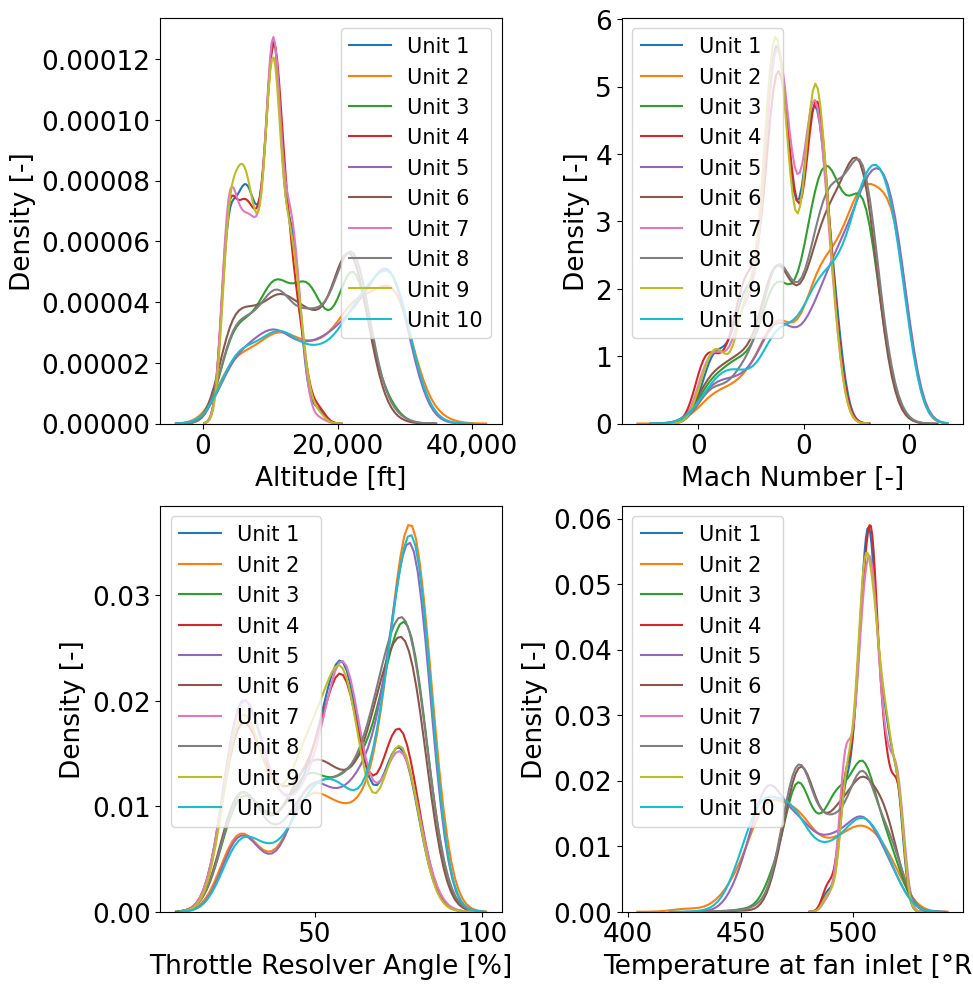

In [109]:
variables = ['alt', 'Mach', 'TRA', 'T2']
labels = ['Altitude [ft]', 'Mach Number [-]', 'Throttle Resolver Angle [%]', 'Temperature at fan inlet [°R]']
size = 10

units = list(np.unique(df_A['unit']))
leg = ['Unit ' + str(int(u)) for u in units]

plot_kde(
    leg,
    variables,
    labels,
    size,
    units,
    df_W,
    df_A,
    labelsize=19,
    name='kde_DS02.png',
    max_samples_per_unit=1500
)

## 2.3. Degradation ($\theta$)

In [110]:
df_T = DataFrame(data=T, columns=T_var) 
df_T['unit'] = df_A['unit'].values
df_T['cycle'] = df_A['cycle'].values
df_Ts = df_T.drop_duplicates()
df_Ts.describe()

,fan_eff_mod,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod,unit,cycle
count,894.0,894.0,894.0,894.0,894.0,894.0,894.000000,894.0,894.0,894.0,894.000000,894.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,-0.003893,0.0,0.0,0.0,5.392617,45.551454
std,0.0,0.0,0.0,0.0,0.0,0.0,0.004207,0.0,0.0,0.0,2.842879,26.409073
min,0.0,0.0,0.0,0.0,0.0,0.0,-0.018806,0.0,0.0,0.0,1.000000,1.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,-0.005124,0.0,0.0,0.0,3.000000,23.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,-0.001917,0.0,0.0,0.0,5.000000,45.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,-0.001091,0.0,0.0,0.0,8.000000,67.750000
max,0.0,0.0,0.0,0.0,0.0,0.0,-0.000117,0.0,0.0,0.0,10.000000,100.000000


In [111]:
import plotly.express as px
varsel = ['unit', 'HPT_eff_mod', 'LPT_eff_mod', 'LPT_flow_mod']
df_Tss = df_Ts.loc[:,varsel]
fig = px.parallel_coordinates(df_Tss, color="unit", labels={"unit": "Units",
                              "HPT_eff_mod": "HPT_eff_mod", "LPT_eff_mod": "LPT_eff_mod",
                              "LPT_flow_mod": "LPT_flow_mod", },
                              color_continuous_scale=px.colors.diverging.Tealrose,
                              color_continuous_midpoint=2)
fig.show()

<Figure size 640x480 with 0 Axes>

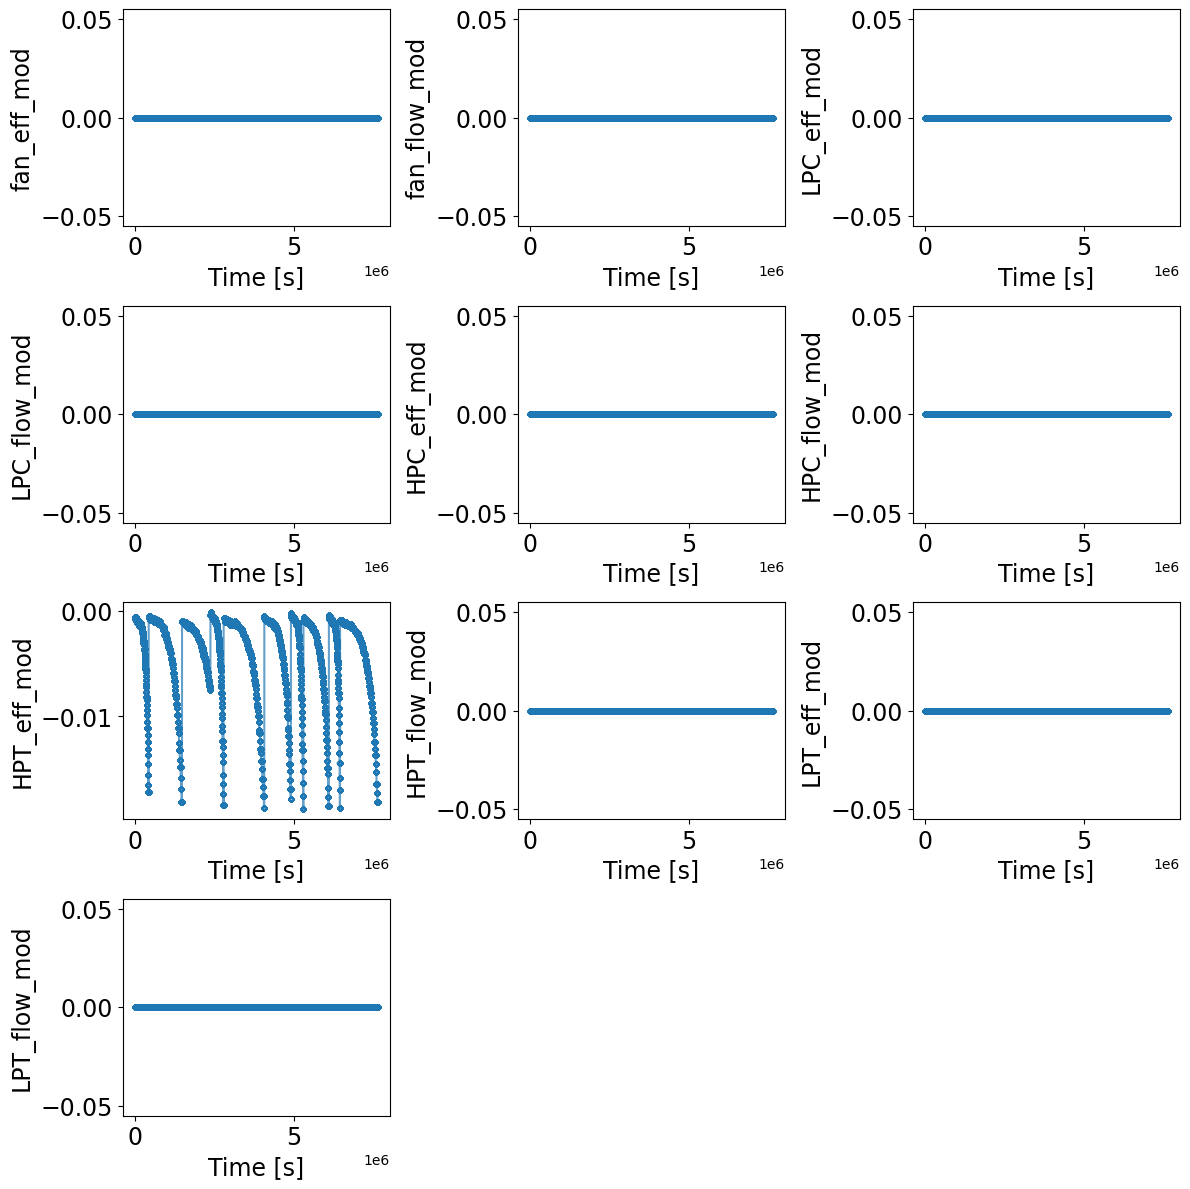

In [112]:
labels = T_var
plot_df_single_color(df_T, T_var , labels)

<Figure size 640x480 with 0 Axes>

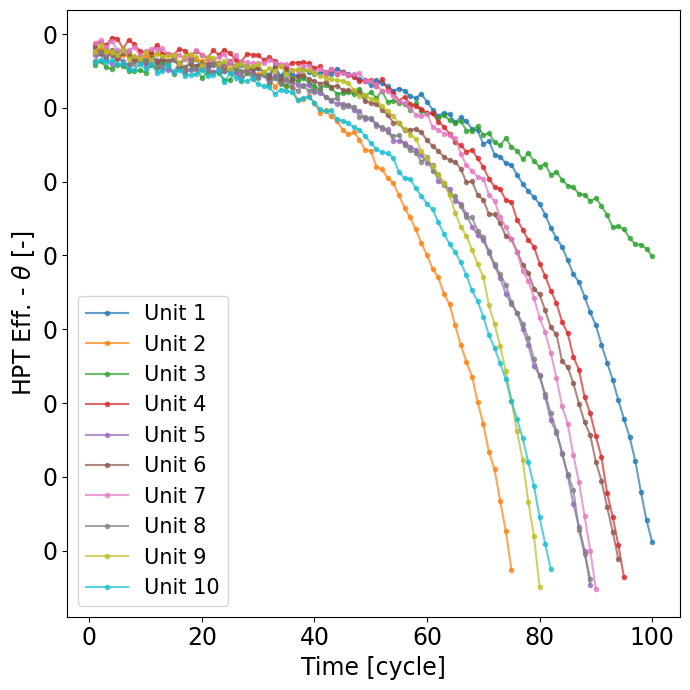

In [113]:
plot_df_color_per_unit(df_Ts, ['HPT_eff_mod'], [r'HPT Eff. - $\theta$ [-]'], size=7,  option='cycle')

## 2.4. Sensor readings ($X_s$)

In [114]:
df_X_s = DataFrame(data=X_s, columns=X_s_var) 

###  Single Unit 

<Figure size 640x480 with 0 Axes>

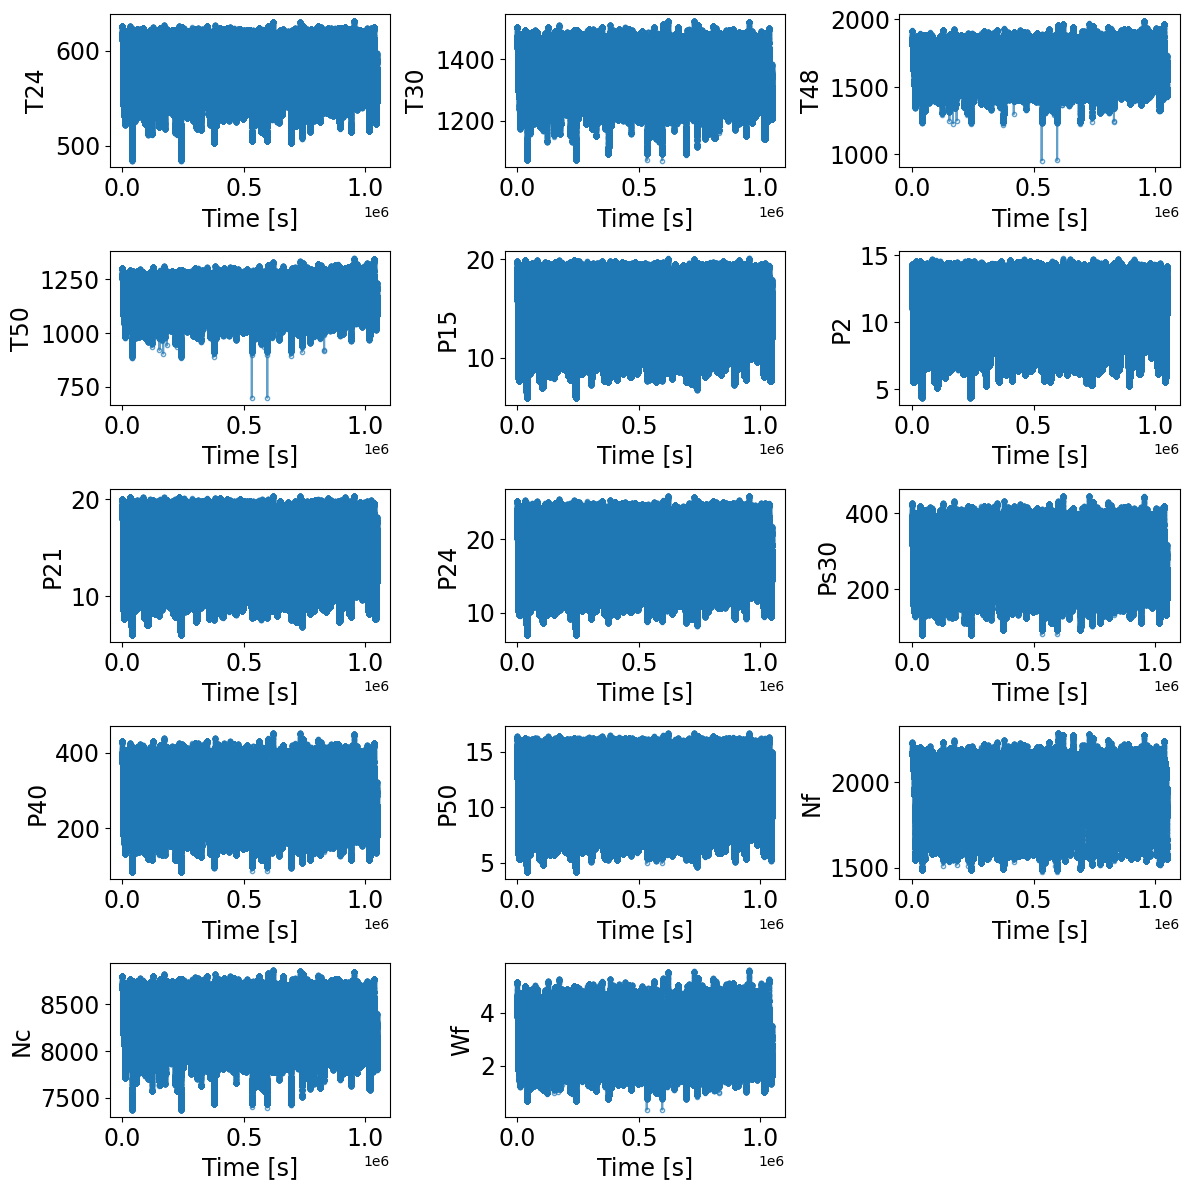

In [115]:
df_X_s_u = df_X_s.loc[df_A.unit == 2]
df_X_s_u.reset_index(inplace=True, drop=True)
labels = X_s_var
plot_df_single_color(df_X_s_u, X_s_var, labels)

###  Single Flight Cycle

<Figure size 640x480 with 0 Axes>

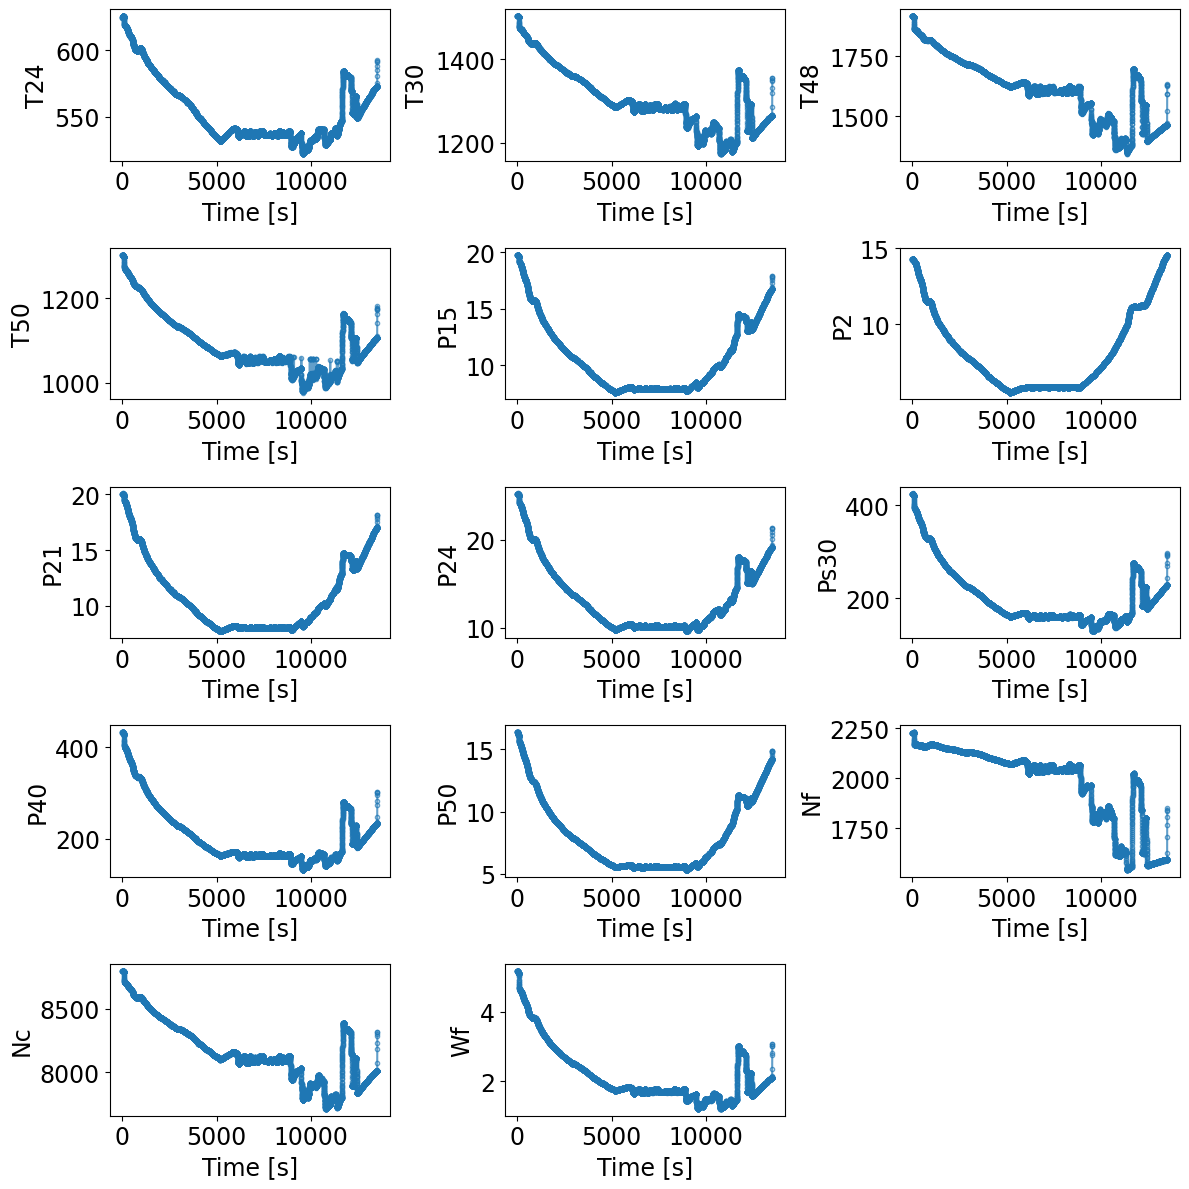

In [116]:
df_X_s_u_c = df_X_s.loc[(df_A.unit == 2) & (df_A.cycle == 1)]
df_X_s_u_c.reset_index(inplace=True, drop=True)
plot_df_single_color(df_X_s_u_c, X_s_var, X_s_var)

## 2.5. Virtual Sensors ($X_v$)

In [117]:
df_X_v = DataFrame(data=X_v, columns=X_v_var) 

<Figure size 640x480 with 0 Axes>

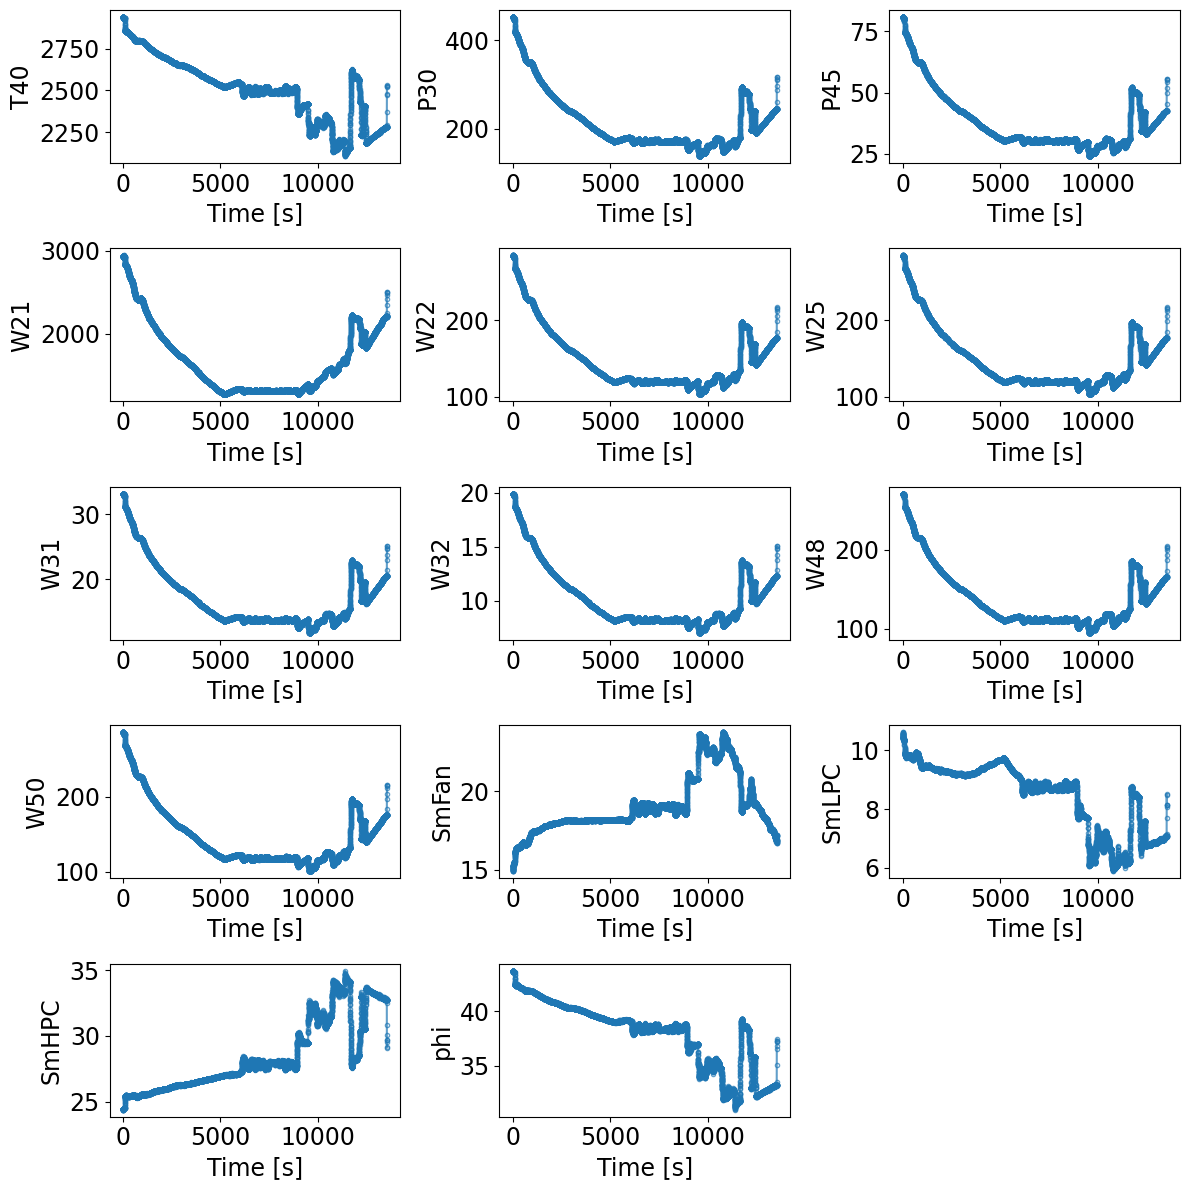

In [118]:
df_X_v_u_c = df_X_v.loc[(df_A.unit == 2) & (df_A.cycle == 1)]
df_X_v_u_c.reset_index(inplace=True, drop=True)
plot_df_single_color(df_X_v_u_c, X_v_var, X_v_var)

## 2.6. Health state ($h_s$)

<Figure size 640x480 with 0 Axes>

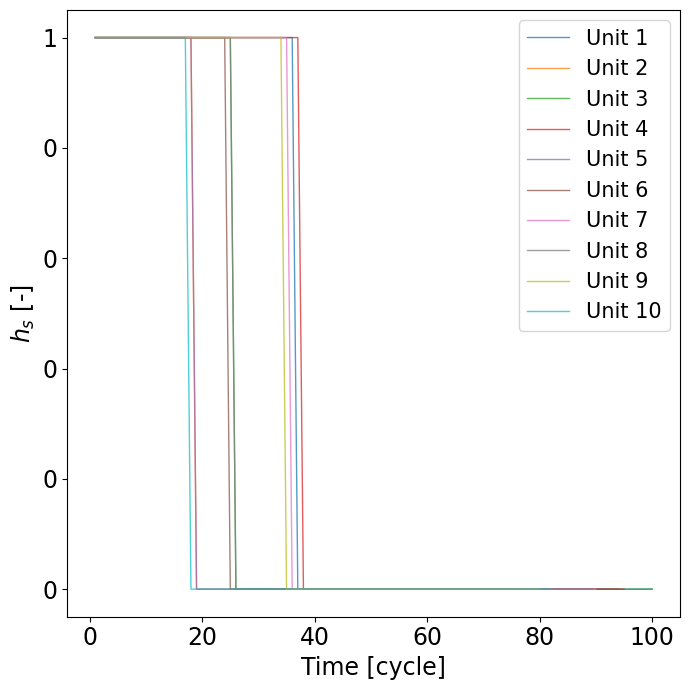

In [119]:
plot_df_color_per_unit(
    df_A,
    ['hs'],
    [r'$h_s$ [-]'],
    option='cycle',
    max_points_per_unit=1500
)

# 3. Hybrid ML Pipeline for RUL Prediction (NASA N-CMAPSS)

## 3.0 Pipeline Overview
- Input assumption: `df_train` and `df_test` are already prepared.
- Modeling strategy: combine gradient-boosting baselines with lightweight classical regressors on engineered temporal features.
- Core contributions:
  1. Baseline benchmark with 5 models (XGBoost, LightGBM, CatBoost, RandomForest, Ridge).
  2. Context-aware processing (flight regime clustering, cluster-wise outlier filtering, PCA).
  3. Explainability using SHAP (global + local near-failure interpretation).

Run the following subsections from top to bottom.

## 3.1 Utility Layer

This utility layer contains reusable functions for:
- Robust schema inference from different column naming conventions.
- Sliding-window feature engineering for variable-length sequences.
- Contextual outlier filtering within each flight regime.

Keeping these utilities modular improves readability, testing, and reusability.

In [120]:
def _find_col_by_priority(columns, priority_exact=None, priority_contains=None):
    """Find the first matching column by exact name, then by substring."""
    priority_exact = priority_exact or []
    priority_contains = priority_contains or []
    col_lc = {c: c.lower() for c in columns}

    for key in priority_exact:
        for c, c_l in col_lc.items():
            if c_l == key.lower():
                return c

    for key in priority_contains:
        for c, c_l in col_lc.items():
            if key.lower() in c_l:
                return c

    return None

In [121]:
def infer_schema(df):
    """Infer key groups: unit, cycle, target, operating conditions, sensors."""
    cols = list(df.columns)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_lc = {c: c.lower() for c in cols}

    unit_col = _find_col_by_priority(
        cols,
        priority_exact=["unit", "unit_id", "engine_id", "id"],
        priority_contains=["unit", "engine"]
    )
    cycle_col = _find_col_by_priority(
        cols,
        priority_exact=["cycle", "time", "t"],
        priority_contains=["cycle", "time", "timestamp"]
    )
    rul_col = _find_col_by_priority(
        cols,
        priority_exact=["rul", "target", "y"],
        priority_contains=["rul"]
    )

    # Detect W variables by known keywords.
    w_keywords = ["alt", "mach", "throttle", "tra"]
    w_cols = [
        c for c in cols
        if c in num_cols and (any(k in cols_lc[c] for k in w_keywords) or cols_lc[c].startswith("w"))
    ]
    w_cols = list(dict.fromkeys(w_cols))

    # Detect sensor groups by naming pattern.
    xs_cols = [c for c in num_cols if ("xs" in cols_lc[c] or "physical" in cols_lc[c])]
    xv_cols = [c for c in num_cols if ("xv" in cols_lc[c] or "virtual" in cols_lc[c])]

    protected = {x for x in [unit_col, cycle_col, rul_col] if x is not None}
    protected.update(w_cols)

    if len(xs_cols) == 0 and len(xv_cols) == 0:
        xs_cols = [c for c in num_cols if c not in protected]

    xs_cols = [c for c in xs_cols if c not in protected]
    xv_cols = [c for c in xv_cols if c not in protected and c not in xs_cols]

    schema = {
        "unit_col": unit_col,
        "cycle_col": cycle_col,
        "rul_col": rul_col,
        "w_cols": w_cols,
        "xs_cols": xs_cols,
        "xv_cols": xv_cols
    }

    missing = [k for k in ["unit_col", "cycle_col", "rul_col"] if schema[k] is None]
    if missing:
        raise ValueError(f"Missing required columns after inference: {missing}. Please set them manually.")
    if len(schema["w_cols"]) == 0:
        raise ValueError("No operating condition columns were inferred. Please set w_cols manually.")
    if len(schema["xs_cols"]) == 0 and len(schema["xv_cols"]) == 0:
        raise ValueError("No sensor columns were inferred.")

    return schema

In [122]:
def _downcast_numeric_columns(df):
    """Reduce memory usage by downcasting numeric dtypes."""
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    for c in num_cols:
        if pd.api.types.is_float_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], downcast="float")
        elif pd.api.types.is_integer_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], downcast="integer")
    return out

In [123]:
def _select_sensor_subset(sensor_cols, max_sensors=None):
    """Limit sensors for OOM protection while preserving order."""
    selected = list(sensor_cols)
    if max_sensors is not None and len(selected) > max_sensors:
        selected = selected[:max_sensors]
    return selected


def _build_sensor_feature_block(df_sorted, grouped, sensor_name, window, lag_steps, include_ema, include_trend):
    """Create temporal features for one sensor and return generated column names."""
    s_group = grouped[sensor_name]
    roll = s_group.rolling(window=window, min_periods=window)

    generated_cols = []

    base_stats = {
        f"{sensor_name}_mean_w{window}": roll.mean().reset_index(level=0, drop=True),
        f"{sensor_name}_std_w{window}": roll.std().reset_index(level=0, drop=True),
        f"{sensor_name}_min_w{window}": roll.min().reset_index(level=0, drop=True),
        f"{sensor_name}_max_w{window}": roll.max().reset_index(level=0, drop=True),
    }

    for col_name, values in base_stats.items():
        df_sorted[col_name] = values.astype(np.float32)
        generated_cols.append(col_name)

    for lag_k in lag_steps:
        col_name = f"{sensor_name}_lag{lag_k}"
        df_sorted[col_name] = s_group.shift(lag_k).astype(np.float32)
        generated_cols.append(col_name)

    diff_col = f"{sensor_name}_diff1"
    df_sorted[diff_col] = s_group.diff(1).astype(np.float32)
    generated_cols.append(diff_col)

    if include_ema:
        ema_col = f"{sensor_name}_ema_w{window}"
        df_sorted[ema_col] = s_group.transform(
            lambda x: x.ewm(span=window, adjust=False).mean()
        ).astype(np.float32)
        generated_cols.append(ema_col)

    if include_trend:
        trend_col = f"{sensor_name}_trend_w{window}"
        df_sorted[trend_col] = s_group.transform(
            lambda x: x.rolling(window=window, min_periods=window).apply(
                lambda v: v[-1] - v[0], raw=True
            )
        ).astype(np.float32)
        generated_cols.append(trend_col)

    return generated_cols

In [124]:
def add_sliding_window_stats(
    df,
    unit_col,
    cycle_col,
    sensor_cols,
    window=30,
    lag_steps=(1, 5),
    include_ema=False,
    include_trend=False,
    max_sensors=None
):
    """Create memory-safe temporal features per engine trajectory."""
    if len(sensor_cols) == 0:
        raise ValueError("sensor_cols is empty. Cannot create temporal features.")

    selected_sensors = _select_sensor_subset(sensor_cols, max_sensors=max_sensors)

    df_sorted = df.sort_values([unit_col, cycle_col]).copy()
    df_sorted = _downcast_numeric_columns(df_sorted)
    grouped = df_sorted.groupby(unit_col, sort=False)

    stat_columns = []
    sensor_stat_map = {}

    for sensor_name in selected_sensors:
        sensor_cols_generated = _build_sensor_feature_block(
            df_sorted=df_sorted,
            grouped=grouped,
            sensor_name=sensor_name,
            window=window,
            lag_steps=lag_steps,
            include_ema=include_ema,
            include_trend=include_trend
        )
        sensor_stat_map[sensor_name] = sensor_cols_generated
        stat_columns.extend(sensor_cols_generated)

    # Drop warm-up rows where history is not long enough.
    max_lag = max(lag_steps) if len(lag_steps) > 0 else 0
    min_cycle_required = max(window, max_lag + 1)
    out = df_sorted.groupby(unit_col, group_keys=False).apply(
        lambda g: g.iloc[min_cycle_required - 1:]
    )

    out = out.dropna(subset=stat_columns).reset_index(drop=True)
    return out, stat_columns, sensor_stat_map

## 3.2 Temporal Feature Engineering (Engine-wise)
- Group by engine unit and chronological cycle.
- Build time-aware features from sensor history:
  - Rolling statistics: mean/std/min/max.
  - Lag features: lag-1, lag-5.
  - First-order differences.
  - Exponential moving average (EMA).
  - Window trend proxy (last - first value in window).
- Drop warm-up rows with insufficient history.

In [125]:
# Memory-safe feature engineering configuration.
FE_MAX_SENSORS = 16
FE_INCLUDE_EMA = False
FE_INCLUDE_TREND = False
FE_LAGS = (1, 5)

def _validate_required_arrays(required_names):
    """Ensure all required arrays/metadata exist before building splits."""
    missing_names = [name for name in required_names if name not in globals()]
    if missing_names:
        raise NameError(
            "Could not auto-create df_train/df_val/df_test. "
            f"Missing prerequisites: {missing_names}. "
            "Run the data loading cells in Section 2 first."
        )

def _assemble_supervised_from_dev():
    """Combine dev arrays into one supervised table with target RUL."""
    X_dev_local = pd.concat(
        [
            pd.DataFrame(W_dev, columns=W_var),
            pd.DataFrame(X_s_dev, columns=X_s_var),
            pd.DataFrame(X_v_dev, columns=X_v_var),
            pd.DataFrame(A_dev, columns=A_var)
        ],
        axis=1
    )

    y_dev_local = np.asarray(Y_dev).reshape(-1)
    supervised = X_dev_local.copy()
    supervised["RUL"] = y_dev_local
    return supervised

In [126]:
def _find_unit_column(df_supervised_local):
    """Find engine identifier column for trajectory-wise split."""
    for c in ["unit", "unit_id", "engine_id", "id"]:
        if c in df_supervised_local.columns:
            return c
    raise ValueError(
        "Cannot perform engine-wise split because no unit identifier column was found. "
        "Expected one of: unit, unit_id, engine_id, id."
    )


def _engine_wise_split(df_supervised_local, unit_col_split, train_ratio=0.7, val_ratio=0.15):
    """Split by complete engines to preserve temporal continuity."""
    units_sorted = sorted(df_supervised_local[unit_col_split].dropna().unique().tolist())
    n_units = len(units_sorted)

    if n_units < 3:
        raise ValueError("Need at least 3 engines to create train/val/test splits.")

    n_train = int(np.floor(train_ratio * n_units))
    n_val = int(np.floor(val_ratio * n_units))

    n_train = max(n_train, 1)
    n_val = max(n_val, 1)

    n_test = n_units - n_train - n_val
    if n_test < 1:
        n_test = 1
        if n_train > 1:
            n_train -= 1
        else:
            n_val -= 1

    train_units = units_sorted[:n_train]
    val_units = units_sorted[n_train:n_train + n_val]
    test_units = units_sorted[n_train + n_val:]

    train_df = df_supervised_local[df_supervised_local[unit_col_split].isin(train_units)].copy().reset_index(drop=True)
    val_df = df_supervised_local[df_supervised_local[unit_col_split].isin(val_units)].copy().reset_index(drop=True)
    test_df = df_supervised_local[df_supervised_local[unit_col_split].isin(test_units)].copy().reset_index(drop=True)

    return train_df, val_df, test_df, train_units, val_units, test_units

In [127]:
def _build_splits_if_missing():
    """Create df_train/df_val/df_test once if they are not already present."""
    global df_train, df_val, df_test, y_train, y_val, y_test

    if "df_train" in globals() and "df_val" in globals() and "df_test" in globals():
        return

    required_names = [
        "W_dev", "X_s_dev", "X_v_dev", "A_dev", "Y_dev",
        "W_var", "X_s_var", "X_v_var", "A_var"
    ]
    _validate_required_arrays(required_names)

    df_supervised_local = _assemble_supervised_from_dev()
    unit_col_split = _find_unit_column(df_supervised_local)

    (
        df_train,
        df_val,
        df_test,
        train_units,
        val_units,
        test_units
    ) = _engine_wise_split(
        df_supervised_local=df_supervised_local,
        unit_col_split=unit_col_split,
        train_ratio=0.7,
        val_ratio=0.15
    )

    y_train = df_train["RUL"].copy()
    y_val = df_val["RUL"].copy()
    y_test = df_test["RUL"].copy()

    print(
        "[Split] Engine-wise split from dev set -> "
        f"train={df_train.shape}, val={df_val.shape}, test={df_test.shape}"
    )
    print(
        f"[Split] Engine counts -> train={len(train_units)}, "
        f"val={len(val_units)}, test={len(test_units)}"
    )


# Build dataset splits (if needed) before schema inference.
_build_splits_if_missing()

schema = infer_schema(df_train)
print("[Schema] Inferred column groups:")
for k, v in schema.items():
    value = v if not isinstance(v, list) else f"{len(v)} columns"
    print(f"  - {k}: {value}")

# Unpack schema for downstream phases.
unit_col = schema["unit_col"]
cycle_col = schema["cycle_col"]
rul_col = schema["rul_col"]
w_cols = schema["w_cols"]
xs_cols = schema["xs_cols"]
xv_cols = schema["xv_cols"]

sensor_cols_for_stats = list(dict.fromkeys(xs_cols + xv_cols))
if len(sensor_cols_for_stats) > FE_MAX_SENSORS:
    print(
        f"OM guard enabled: reducing sensors from "
        f"{len(sensor_cols_for_stats)} to {FE_MAX_SENSORS}."
    )

print(
    f"Creating temporal stats with window={WINDOW_SIZE}, "
    f"lags={FE_LAGS}, ema={FE_INCLUDE_EMA}, trend={FE_INCLUDE_TREND}..."
)

[Schema] Inferred column groups:
  - unit_col: unit
  - cycle_col: cycle
  - rul_col: RUL
  - w_cols: 11 columns
  - xs_cols: 23 columns
  - xv_cols: 0 columns
OM guard enabled: reducing sensors from 23 to 16.
Creating temporal stats with window=20, lags=(1, 5), ema=False, trend=False...


In [128]:
def _run_temporal_fe(split_df):
    """Run the same temporal feature pipeline on one split."""
    return add_sliding_window_stats(
        split_df,
        unit_col,
        cycle_col,
        sensor_cols_for_stats,
        window=WINDOW_SIZE,
        lag_steps=FE_LAGS,
        include_ema=FE_INCLUDE_EMA,
        include_trend=FE_INCLUDE_TREND,
        max_sensors=FE_MAX_SENSORS
    )


train_fe, train_stat_cols, sensor_stat_map = _run_temporal_fe(df_train)
val_fe, val_stat_cols, _ = _run_temporal_fe(df_val)
test_fe, test_stat_cols, _ = _run_temporal_fe(df_test)

print(f"Train shape after rolling/dropna: {train_fe.shape}")
print(f"Val shape after rolling/dropna:   {val_fe.shape}")
print(f"Test shape after rolling/dropna:  {test_fe.shape}")
print(f"Engineered train stat columns:     {len(train_stat_cols)}")
print(f"Engineered val stat columns:       {len(val_stat_cols)}")
print(f"Engineered test stat columns:      {len(test_stat_cols)}")

Train shape after rolling/dropna: (2789563, 148)
Val shape after rolling/dropna:   (1280128, 148)
Test shape after rolling/dropna:  (836831, 148)
Engineered train stat columns:     112
Engineered val stat columns:       112
Engineered test stat columns:      112


## 3.3. Baseline Modeling
- Use all non-target variables as model inputs.
- Train 5 baseline regressors: XGBoost, LightGBM, CatBoost, RandomForest, and Ridge.
- Report RMSE and $R^2$ on validation and test splits, then select the best baseline for Section 4.

In [129]:
def _build_aligned_feature_list(train_df, val_df, test_df, target_col):
    """Use all non-target features that exist in every split."""
    return [
        c for c in train_df.columns
        if c != target_col and c in val_df.columns and c in test_df.columns
    ]


baseline_feature_cols = _build_aligned_feature_list(
    train_df=train_fe,
    val_df=val_fe,
    test_df=test_fe,
    target_col=rul_col
)

if len(baseline_feature_cols) == 0:
    raise ValueError("No baseline feature columns are available after alignment.")

print(f"[Baseline] Number of input features (all non-target): {len(baseline_feature_cols)}")

X_train_base = train_fe[baseline_feature_cols].copy()
y_train_base = train_fe[rul_col].copy()
X_val_base = val_fe[baseline_feature_cols].copy()
y_val_base = val_fe[rul_col].copy()
X_test_base = test_fe[baseline_feature_cols].copy()
y_test_base = test_fe[rul_col].copy()

[Baseline] Number of input features (all non-target): 147


In [130]:
# DL baseline configuration (speed-priority profile with distributed training support).
import os
import json
import shutil
import zipfile
from datetime import datetime
from contextlib import nullcontext

DL_EPOCHS = 14
DL_EARLY_STOP_PATIENCE = 3
DL_MIN_DELTA = 2e-4
DL_BATCH_SIZE_PER_REPLICA = 256
BASELINE_MAX_TRAIN_ROWS = 800000
USE_TF_DEEP_BASELINES = False
CHECKPOINT_METRIC_NAME = "val_rmse"
CHECKPOINT_METRIC_MODE = "min"
RESUME_FROM_LAST_CHECKPOINT = True

CHECKPOINT_ROOT = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
CHECKPOINT_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
CHECKPOINT_DIR = os.path.join(CHECKPOINT_ROOT, f"train_checkpoints_{CHECKPOINT_TAG}")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"[Checkpoint] Directory: {CHECKPOINT_DIR}")
BEST_CHECKPOINT_TRACKER = {}


def _sanitize_name(name):
    return name.lower().replace("-", "_").replace(" ", "_")


def _checkpoint_extension(model_name):
    return ".weights.h5" if _is_deep_model(model_name) else ".joblib"


def _find_latest_checkpoint_dir(root_dir, current_dir):
    candidates = []
    for name in os.listdir(root_dir):
        if not name.startswith("train_checkpoints_"):
            continue
        path = os.path.join(root_dir, name)
        if not os.path.isdir(path) or os.path.abspath(path) == os.path.abspath(current_dir):
            continue
        candidates.append(path)

    if not candidates:
        return None

    candidates.sort(key=os.path.getmtime, reverse=True)
    return candidates[0]


LATEST_CHECKPOINT_DIR = _find_latest_checkpoint_dir(CHECKPOINT_ROOT, CHECKPOINT_DIR)
if LATEST_CHECKPOINT_DIR is not None:
    print(f"[Checkpoint] Latest checkpoint found: {LATEST_CHECKPOINT_DIR}")
else:
    print("[Checkpoint] No previous checkpoint directory found.")


def _resume_model_from_latest(stage, model_name, model):
    """Resume from latest checkpoint when available."""
    if not RESUME_FROM_LAST_CHECKPOINT or LATEST_CHECKPOINT_DIR is None:
        return model, False

    ckpt_path = os.path.join(
        LATEST_CHECKPOINT_DIR,
        _sanitize_name(stage),
        f"{_sanitize_name(model_name)}{_checkpoint_extension(model_name)}"
    )
    if not os.path.exists(ckpt_path):
        return model, False

    try:
        if _is_deep_model(model_name):
            model.load_weights(ckpt_path)
            print(f"[Checkpoint] Resumed weights for {model_name} from {ckpt_path}")
            return model, True

        import joblib
        loaded_model = joblib.load(ckpt_path)
        print(f"[Checkpoint] Loaded full model for {model_name} from {ckpt_path}")
        return loaded_model, True
    except Exception as exc:
        print(f"[Checkpoint] Resume failed for {model_name}: {exc}")
        return model, False


def _is_better_metric(new_value, old_value, mode):
    if old_value is None:
        return True
    if mode == "max":
        return new_value > old_value
    return new_value < old_value


def _save_model_checkpoint(stage, model_name, model, metrics=None, metric_name=None, metric_mode="min"):
    """Save model artifact right after training finishes."""
    safe_stage = _sanitize_name(stage)
    safe_model = _sanitize_name(model_name)

    model_dir = os.path.join(CHECKPOINT_DIR, safe_stage)
    os.makedirs(model_dir, exist_ok=True)

    if _is_deep_model(model_name):
        model_path = os.path.join(model_dir, f"{safe_model}.weights.h5")
        model.save_weights(model_path)
    else:
        try:
            import joblib
            model_path = os.path.join(model_dir, f"{safe_model}.joblib")
            joblib.dump(model, model_path)
        except Exception:
            import pickle
            model_path = os.path.join(model_dir, f"{safe_model}.pkl")
            with open(model_path, "wb") as f:
                pickle.dump(model, f)

    if metrics is not None:
        metrics_path = os.path.join(model_dir, f"{safe_model}.metrics.json")
        with open(metrics_path, "w", encoding="utf-8") as f:
            json.dump(metrics, f, indent=2, ensure_ascii=True)

    if metrics is not None and metric_name is not None and metric_name in metrics:
        metric_value = float(metrics[metric_name])
        best_old = BEST_CHECKPOINT_TRACKER.get(stage, {}).get("metric_value")
        if _is_better_metric(metric_value, best_old, metric_mode):
            best_path = os.path.join(model_dir, f"best_{safe_model}{_checkpoint_extension(model_name)}")
            shutil.copy2(model_path, best_path)
            BEST_CHECKPOINT_TRACKER[stage] = {
                "model_name": model_name,
                "metric_name": metric_name,
                "metric_value": metric_value,
                "path": best_path
            }
            best_meta_path = os.path.join(model_dir, "best_checkpoint.json")
            with open(best_meta_path, "w", encoding="utf-8") as f:
                json.dump(BEST_CHECKPOINT_TRACKER[stage], f, indent=2, ensure_ascii=True)
            print(
                f"[Checkpoint] New best ({stage}) -> {model_name} | "
                f"{metric_name}={metric_value:.6f}"
            )

    print(f"[Checkpoint] Saved {model_name} ({stage}) -> {model_path}")
    return model_path


def _zip_all_checkpoints():
    """Archive all current-run checkpoints into one zip file."""
    zip_path = os.path.join(CHECKPOINT_ROOT, f"{os.path.basename(CHECKPOINT_DIR)}.zip")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(CHECKPOINT_DIR):
            for name in files:
                src = os.path.join(root, name)
                arc = os.path.relpath(src, CHECKPOINT_DIR)
                zf.write(src, arcname=arc)
    print(f"[Checkpoint] Zipped all checkpoints -> {zip_path}")
    return zip_path

def _try_init_tpu(tf, tpu_name):
    """Try initializing TPU strategy for a specific TPU name/address."""
    resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu=tpu_name)
    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)
    strategy = tf.distribute.TPUStrategy(resolver)
    return strategy


def _init_tf_accelerator(seed):
    """Auto-detect TPU/GPU and create TensorFlow distribution strategy."""
    if not USE_TF_DEEP_BASELINES:
        print("[Accel] Deep TensorFlow baselines are disabled. Using CPU strategy.")
        return None, "CPU", 1

    # Kaggle TPU runtime usually exposes TPU_NAME.
    tpu_env_name = os.environ.get("TPU_NAME")
    if tpu_env_name:
        # Avoid unnecessary CUDA probing noise when TPU is intended.
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

    try:
        import tensorflow as tf
    except ImportError:
        print("[Accel] TensorFlow not installed. Falling back to CPU mode.")
        return None, "CPU", 1

    tf.keras.utils.set_random_seed(seed)

    tpu_candidates = []
    if tpu_env_name:
        tpu_candidates.append(tpu_env_name)
    # Also try auto-resolver path for compatibility across TF versions/environments.
    tpu_candidates.append(None)

    for tpu_name in tpu_candidates:
        try:
            strategy = _try_init_tpu(tf, tpu_name)
            tf.keras.mixed_precision.set_global_policy("mixed_bfloat16")
            replicas = int(strategy.num_replicas_in_sync)
            print(f"[Accel] TPU detected. name={tpu_name or 'auto'} | replicas={replicas}")
            return strategy, "TPU", replicas
        except Exception as exc:
            print(f"[Accel] TPU init failed for name={tpu_name or 'auto'}: {exc}")

    gpus = tf.config.list_physical_devices("GPU")
    if len(gpus) > 0:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except Exception:
                pass

        if len(gpus) >= 2:
            strategy = tf.distribute.MirroredStrategy()
            tf.keras.mixed_precision.set_global_policy("mixed_float16")
            print(f"[Accel] Multi-GPU detected ({len(gpus)} GPUs). Using MirroredStrategy.")
            return strategy, f"GPUx{len(gpus)}", int(strategy.num_replicas_in_sync)

        # Single GPU case.
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
        print("[Accel] Single GPU detected. Using OneDeviceStrategy.")
        return strategy, "GPUx1", 1

    print("[Accel] No TPU/GPU detected. Using CPU.")
    print(f"[Accel] Debug env -> TPU_NAME={os.environ.get('TPU_NAME')} | KAGGLE_KERNEL_RUN_TYPE={os.environ.get('KAGGLE_KERNEL_RUN_TYPE')}")
    return None, "CPU", 1


TF_STRATEGY, ACCELERATOR_TYPE, N_REPLICAS = _init_tf_accelerator(SEED)
DL_GLOBAL_BATCH_SIZE = DL_BATCH_SIZE_PER_REPLICA * max(N_REPLICAS, 1)
print(f"[Accel] Mode={ACCELERATOR_TYPE} | Global batch size={DL_GLOBAL_BATCH_SIZE}")

def _strategy_scope():
    """Return strategy scope when available."""
    if TF_STRATEGY is None:
        return nullcontext()
    return TF_STRATEGY.scope()


def _set_tf_seed(seed):
    """Set TensorFlow random seed if TensorFlow is available."""
    try:
        import tensorflow as tf
        tf.keras.utils.set_random_seed(seed)
    except ImportError:
        pass


def _to_sequence_tensor(X):
    """Convert 2D tabular matrix to 3D tensor for sequence models."""
    arr = np.asarray(X, dtype=np.float32)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D input for sequence conversion, got shape={arr.shape}")
    return arr.reshape(arr.shape[0], arr.shape[1], 1)


def _make_tf_dataset(X, y, batch_size, training, seed):
    """Build optimized tf.data pipeline for deep model training."""
    try:
        import tensorflow as tf
    except ImportError as exc:
        raise ImportError("TensorFlow is required for deep model training.") from exc

    X_seq = _to_sequence_tensor(X)
    y_arr = np.asarray(y, dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices((X_seq, y_arr))

    if training:
        shuffle_size = min(len(y_arr), 200000)
        ds = ds.shuffle(shuffle_size, seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return ds


def _build_disabled_seq_regressor_a(input_steps, seed):
    """Deep sequence baseline removed from this notebook variant."""
    raise RuntimeError("Deep sequence baselines are disabled in this notebook.")


def _build_disabled_seq_regressor_b(input_steps, seed):
    """Deep sequence baseline removed from this notebook variant."""
    raise RuntimeError("Deep sequence baselines are disabled in this notebook.")


def _is_deep_model(model_name):
    return False


def _fit_model_by_name(model_name, model, X_train, y_train, X_val=None, y_val=None, progress_label=None):
    """Unified fit routine for tree models and deep models."""
    label = progress_label or model_name
    print(f"[Train] {label}: started")
    if _is_deep_model(model_name):
        try:
            from tensorflow.keras.callbacks import EarlyStopping
        except ImportError as exc:
            raise ImportError(
                "TensorFlow is not installed. Please install with: pip install tensorflow"
            ) from exc

        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                patience=DL_EARLY_STOP_PATIENCE,
                min_delta=DL_MIN_DELTA,
                restore_best_weights=True
            )
        ]

        train_ds = _make_tf_dataset(
            X=X_train,
            y=y_train,
            batch_size=DL_GLOBAL_BATCH_SIZE,
            training=True,
            seed=SEED
        )

        validation_data = None
        if X_val is not None and y_val is not None:
            validation_data = _make_tf_dataset(
                X=X_val,
                y=y_val,
                batch_size=DL_GLOBAL_BATCH_SIZE,
                training=False,
                seed=SEED
            )

        history = model.fit(
            train_ds,
            validation_data=validation_data,
            epochs=DL_EPOCHS,
            callbacks=callbacks,
            verbose=1
        )
        last_loss = float(history.history["loss"][-1]) if "loss" in history.history else float("nan")
        if "val_loss" in history.history:
            best_val = float(np.min(history.history["val_loss"]))
            print(f"[Train] {label}: done | last_loss={last_loss:.6f} | best_val_loss={best_val:.6f}")
        else:
            print(f"[Train] {label}: done | last_loss={last_loss:.6f}")
        return history

    if model_name == "CatBoost":
        model.fit(X_train, y_train, verbose=100)
        print(f"[Train] {label}: done")
        return None

    if model_name == "XGBoost":
        fit_kwargs = {}
        if X_val is not None and y_val is not None:
            fit_kwargs = {"eval_set": [(X_val, y_val)], "verbose": 50}
        model.fit(X_train, y_train, **fit_kwargs)
        print(f"[Train] {label}: done")
        return None

    if model_name == "LightGBM":
        fit_kwargs = {}
        if X_val is not None and y_val is not None:
            fit_kwargs = {"eval_set": [(X_val, y_val)]}
        model.fit(X_train, y_train, **fit_kwargs)
        print(f"[Train] {label}: done")
        return None

    model.fit(X_train, y_train)
    print(f"[Train] {label}: done")
    return None


def _predict_model_by_name(model_name, model, X):
    """Unified predict routine for tree models and deep models."""
    if _is_deep_model(model_name):
        pred = model.predict(_to_sequence_tensor(X), verbose=0).reshape(-1)
        return pred.astype(np.float32)
    return model.predict(X)


def _sample_for_speed(X, y, max_rows, seed):
    """Sample training rows for speed-priority mode."""
    if len(X) <= max_rows:
        return X, y

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=max_rows, replace=False)

    if isinstance(X, pd.DataFrame):
        X_out = X.iloc[idx].reset_index(drop=True)
    else:
        X_out = np.asarray(X)[idx]

    if isinstance(y, (pd.Series, pd.DataFrame)):
        y_out = y.iloc[idx].reset_index(drop=True)
    else:
        y_out = np.asarray(y)[idx]

    print(f"[Baseline] Speed mode sampling: {len(X):,} -> {len(X_out):,} rows")
    return X_out, y_out


def _build_baseline_candidates(seed, input_steps):
    """Create 5 baseline regressors: XGBoost, LightGBM, CatBoost, RandomForest, Ridge."""
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import Ridge
    try:
        from lightgbm import LGBMRegressor
    except ImportError as exc:
        raise ImportError(
            "LightGBM is not installed. Please install with: pip install lightgbm"
        ) from exc

    try:
        from catboost import CatBoostRegressor
    except ImportError as exc:
        raise ImportError(
            "CatBoost is not installed. Please install with: pip install catboost"
        ) from exc

    xgb_kwargs = {
        "n_estimators": 320,
        "learning_rate": 0.08,
        "max_depth": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "objective": "reg:squarederror",
        "random_state": seed,
        "n_jobs": -1
    }
    if ACCELERATOR_TYPE.startswith("GPU"):
        xgb_kwargs.update({"tree_method": "hist", "device": "cuda"})

    catboost_kwargs = {
        "iterations": 320,
        "learning_rate": 0.08,
        "depth": 5,
        "loss_function": "RMSE",
        "random_seed": seed,
        "verbose": False,
        "allow_writing_files": False
    }
    if ACCELERATOR_TYPE.startswith("GPU"):
        catboost_kwargs.update({"task_type": "GPU"})

    models = {
        "XGBoost": XGBRegressor(**xgb_kwargs),
        "LightGBM": LGBMRegressor(
            n_estimators=320,
            learning_rate=0.08,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=seed,
            n_jobs=-1
        ),
        "CatBoost": CatBoostRegressor(**catboost_kwargs),
        "RandomForest": RandomForestRegressor(
            n_estimators=160,
            max_depth=14,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1
        ),
        "Ridge": Ridge(alpha=1.0)
    }
    return models


X_train_fit, y_train_fit = _sample_for_speed(
    X=X_train_base,
    y=y_train_base,
    max_rows=BASELINE_MAX_TRAIN_ROWS,
    seed=SEED
)

baseline_models = _build_baseline_candidates(SEED, input_steps=X_train_base.shape[1])
trained_baseline_models = {}
baseline_pred_cache = {}
baseline_history_cache = {}
baseline_rows = []

print(
    "[Baseline] Training 5 baseline models (speed-priority, distributed when TPU/GPU available)..."
 )
total_models = len(baseline_models)
for idx, (model_name, model) in enumerate(baseline_models.items(), start=1):
    print(f"  -> Training {model_name} ({idx}/{total_models})...")
    model, resumed = _resume_model_from_latest("baseline", model_name, model)
    if resumed and not _is_deep_model(model_name):
        print(f"[Train] {idx}/{total_models} {model_name}: resumed and skipped refit")
        history = None
    else:
        history = _fit_model_by_name(
            model_name=model_name,
            model=model,
            X_train=X_train_fit,
            y_train=y_train_fit,
            X_val=X_val_base,
            y_val=y_val_base,
            progress_label=f"{idx}/{total_models} {model_name}"
        )

    pred_val = _predict_model_by_name(model_name, model, X_val_base)
    pred_test = _predict_model_by_name(model_name, model, X_test_base)

    val_rmse = np.sqrt(mean_squared_error(y_val_base, pred_val))
    val_r2 = r2_score(y_val_base, pred_val)
    test_rmse = np.sqrt(mean_squared_error(y_test_base, pred_test))
    test_r2 = r2_score(y_test_base, pred_test)

    trained_baseline_models[model_name] = model
    baseline_pred_cache[model_name] = {
        "val_pred": pred_val,
        "test_pred": pred_test
    }
    baseline_history_cache[model_name] = history.history if history is not None else None
    baseline_rows.append({
        "model": model_name,
        "val_rmse": val_rmse,
        "val_r2": val_r2,
        "test_rmse": test_rmse,
        "test_r2": test_r2
    })

    _save_model_checkpoint(
        stage="baseline",
        model_name=model_name,
        model=model,
        metrics={
            "val_rmse": float(val_rmse),
            "val_r2": float(val_r2),
            "test_rmse": float(test_rmse),
            "test_r2": float(test_r2)
        },
        metric_name=CHECKPOINT_METRIC_NAME,
        metric_mode=CHECKPOINT_METRIC_MODE
    )

baseline_compare_df = pd.DataFrame(baseline_rows).sort_values(
    by=["val_rmse", "val_r2"],
    ascending=[True, False]
).reset_index(drop=True)

print("\n[Baseline] Comparison table:")
display(baseline_compare_df)

best_baseline_name = baseline_compare_df.loc[0, "model"]
baseline_model = trained_baseline_models[best_baseline_name]

# Keep downstream variable names for compatibility with next sections.
val_pred = baseline_pred_cache[best_baseline_name]["val_pred"]
base_pred = baseline_pred_cache[best_baseline_name]["test_pred"]
rmse_val = float(baseline_compare_df.loc[0, "val_rmse"])
r2_val = float(baseline_compare_df.loc[0, "val_r2"])
rmse_base = float(baseline_compare_df.loc[0, "test_rmse"])
r2_base = float(baseline_compare_df.loc[0, "test_r2"])

print(f"\n[Baseline] Best model selected for next phases: {best_baseline_name}")
print(f"[Baseline] Validation RMSE: {rmse_val:.4f} | R2: {r2_val:.4f}")
print(f"[Baseline] Test RMSE:       {rmse_base:.4f} | R2: {r2_base:.4f}")
_zip_all_checkpoints()

[Checkpoint] Directory: /kaggle/working/train_checkpoints_20260407_102839
[Checkpoint] Latest checkpoint found: /kaggle/working/train_checkpoints_20260407_102034
[Accel] Deep TensorFlow baselines are disabled. Using CPU strategy.
[Accel] Mode=CPU | Global batch size=256
[Baseline] Speed mode sampling: 2,789,563 -> 800,000 rows
[Baseline] Training 5 baseline models (speed-priority, distributed when TPU/GPU available)...
  -> Training XGBoost (1/5)...
[Checkpoint] Loaded full model for XGBoost from /kaggle/working/train_checkpoints_20260407_102034/baseline/xgboost.joblib
[Train] 1/5 XGBoost: resumed and skipped refit
[Checkpoint] New best (baseline) -> XGBoost | val_rmse=12.923611
[Checkpoint] Saved XGBoost (baseline) -> /kaggle/working/train_checkpoints_20260407_102839/baseline/xgboost.joblib
  -> Training LightGBM (2/5)...
[Checkpoint] Loaded full model for LightGBM from /kaggle/working/train_checkpoints_20260407_102034/baseline/lightgbm.joblib
[Train] 2/5 LightGBM: resumed and skipped

,model,val_rmse,val_r2,test_rmse,test_r2
0,Ridge,10.373079,0.836383,3.847953,0.979917
1,LightGBM,12.680123,0.755511,5.426716,0.960056
2,XGBoost,12.923611,0.746031,5.671446,0.956372
3,RandomForest,13.337365,0.729509,5.988419,0.951359
4,CatBoost,13.750016,0.712512,5.915156,0.952542



[Baseline] Best model selected for next phases: Ridge
[Baseline] Validation RMSE: 10.3731 | R2: 0.8364
[Baseline] Test RMSE:       3.8480 | R2: 0.9799
[Checkpoint] Zipped all checkpoints -> /kaggle/working/train_checkpoints_20260407_102839.zip


'/kaggle/working/train_checkpoints_20260407_102839.zip'

[Baseline-Viz] Scatter sampled: 12,000 / 836,831


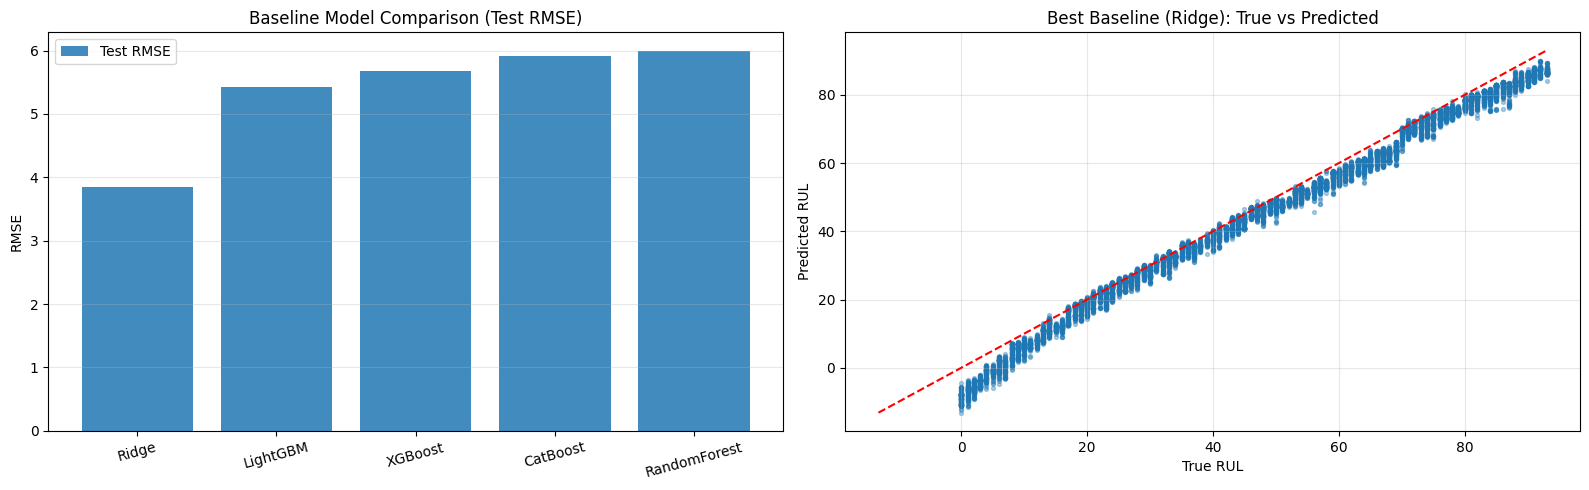

In [131]:
# Baseline visualization for 5-model comparison + selected best model (lightweight).
if "baseline_compare_df" not in globals():
    raise NameError("baseline_compare_df is missing. Run the baseline training cell first.")

if "best_baseline_name" not in globals():
    raise NameError("best_baseline_name is missing. Run the baseline training cell first.")

BASELINE_SCATTER_MAX_POINTS = 12000

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Bar chart: test RMSE for all baseline models (lower is better).
plot_df = baseline_compare_df.sort_values("test_rmse", ascending=True).reset_index(drop=True)
x_pos = np.arange(len(plot_df))

axes[0].bar(x_pos, plot_df["test_rmse"], alpha=0.85, label="Test RMSE")
axes[0].set_title("Baseline Model Comparison (Test RMSE)")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(plot_df["model"], rotation=15)
axes[0].set_ylabel("RMSE")
axes[0].grid(alpha=0.3, axis="y")
axes[0].legend()

# 2) Scatter: best model prediction quality (sampled for stability).
best_test_pred = np.asarray(baseline_pred_cache[best_baseline_name]["test_pred"], dtype=np.float32)
y_true_all = np.asarray(y_test_base, dtype=np.float32)

n_all = len(y_true_all)
if n_all > BASELINE_SCATTER_MAX_POINTS:
    idx = np.random.default_rng(SEED).choice(n_all, size=BASELINE_SCATTER_MAX_POINTS, replace=False)
    y_scatter = y_true_all[idx]
    pred_scatter = best_test_pred[idx]
    print(f"[Baseline-Viz] Scatter sampled: {BASELINE_SCATTER_MAX_POINTS:,} / {n_all:,}")
else:
    y_scatter = y_true_all
    pred_scatter = best_test_pred

axes[1].scatter(y_scatter, pred_scatter, s=8, alpha=0.35)
min_v = float(min(np.min(y_scatter), np.min(pred_scatter)))
max_v = float(max(np.max(y_scatter), np.max(pred_scatter)))
axes[1].plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.5)
axes[1].set_title(f"Best Baseline ({best_baseline_name}): True vs Predicted")
axes[1].set_xlabel("True RUL")
axes[1].set_ylabel("Predicted RUL")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# No epoch learning curve because deep models were replaced with fast classical models.

In [132]:
# Export all baseline models (Kaggle-friendly).
import os
import json
import zipfile
import joblib
from datetime import datetime

if "trained_baseline_models" not in globals() or "baseline_compare_df" not in globals():
    raise NameError("Baseline artifacts are missing. Run the baseline training cell first.")

export_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_dir = os.path.join(export_dir, f"baseline_models_{stamp}")
os.makedirs(model_dir, exist_ok=True)

exported_files = []

def _safe_export_tree_model(name, model, out_dir):
    paths = []
    safe_name = name.lower().replace("-", "_").replace(" ", "_")
    if name == "XGBoost":
        p_native = os.path.join(out_dir, f"{safe_name}.json")
        model.save_model(p_native)
        paths.append(p_native)
    elif name == "LightGBM":
        p_native = os.path.join(out_dir, f"{safe_name}.txt")
        model.booster_.save_model(p_native)
        paths.append(p_native)
    elif name == "CatBoost":
        p_native = os.path.join(out_dir, f"{safe_name}.cbm")
        model.save_model(p_native)
        paths.append(p_native)

    # Also export sklearn wrapper for quick reload when possible.
    p_joblib = os.path.join(out_dir, f"{safe_name}.joblib")
    joblib.dump(model, p_joblib)
    paths.append(p_joblib)
    return paths


def _safe_export_deep_model(name, model, out_dir):
    safe_name = name.lower().replace("-", "_").replace(" ", "_")
    p_keras = os.path.join(out_dir, f"{safe_name}.keras")
    model.save(p_keras)
    return [p_keras]


for model_name, model_obj in trained_baseline_models.items():
    try:
        if model_name in {"LSTM", "CNN-LSTM"}:
            exported_files.extend(_safe_export_deep_model(model_name, model_obj, model_dir))
        else:
            exported_files.extend(_safe_export_tree_model(model_name, model_obj, model_dir))
    except Exception as exc:
        print(f"[Export] Skip {model_name}: {exc}")

# Save baseline metrics and selected best-model info.
metrics_path = os.path.join(model_dir, "baseline_compare.csv")
baseline_compare_df.to_csv(metrics_path, index=False)
exported_files.append(metrics_path)

meta = {
    "best_baseline_name": best_baseline_name,
    "timestamp": stamp,
    "n_models": int(len(trained_baseline_models))
}
meta_path = os.path.join(model_dir, "baseline_metadata.json")
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=True)
exported_files.append(meta_path)

zip_path = os.path.join(export_dir, f"baseline_models_{stamp}.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in exported_files:
        zf.write(p, arcname=os.path.relpath(p, model_dir))

print("[Export] Baseline artifacts saved:")
print("- folder:", model_dir)
print("- zip   :", zip_path)
print("- best  :", best_baseline_name)

[Export] Baseline artifacts saved:
- folder: /kaggle/working/baseline_models_20260407_102843
- zip   : /kaggle/working/baseline_models_20260407_102843.zip
- best  : Ridge


# 4. Context-Aware Optimization

This subsection implements the physics-aware enhancement pipeline in four explicit parts:
1. Flight regime clustering on operating conditions only.
2. Cluster-wise outlier filtering using IsolationForest.
3. PCA (95% variance) on statistical sensor features to reduce multicollinearity.
4. Retraining the best baseline model on cleaned and reduced features.

Finally, we compare baseline and optimized performance.

## 4.1 Flight Regime Clustering

In [133]:
import os
from contextlib import nullcontext

try:
    from threadpoolctl import threadpool_limits
except ImportError:
    threadpool_limits = None

BLAS_MAX_THREADS = int(os.environ.get("BLAS_MAX_THREADS", "2"))
REGIME_FIT_SAMPLE_MAX = 180_000
REGIME_MINIBATCH_BATCH_SIZE = 4096
REGIME_PREDICT_BATCH_SIZE = 120_000


def _limit_blas_threads(max_threads):
    """Cap BLAS threads to prevent OpenBLAS oversubscription and kernel crashes."""
    max_threads = max(1, int(max_threads))
    for env_var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
        os.environ[env_var] = str(max_threads)

    if threadpool_limits is not None:
        try:
            return threadpool_limits(limits=max_threads, user_api="blas")
        except Exception:
            pass
    return nullcontext()


def _sample_rows_for_kmeans_fit(train_df, w_columns, max_rows, seed):
    """Sample rows for clustering fit to keep memory bounded on Kaggle."""
    n_rows = len(train_df)
    if n_rows <= max_rows:
        return train_df[w_columns].to_numpy(dtype=np.float32, copy=False)

    fit_df = train_df[w_columns].sample(n=max_rows, random_state=seed)
    print(f"[Cluster] Fit sample: {max_rows:,} / {n_rows:,} rows")
    return fit_df.to_numpy(dtype=np.float32, copy=False)


def _fit_regime_kmeans(train_df, w_columns, n_clusters, seed):
    """Fit clustering on operating conditions to define flight regimes."""
    n_rows = len(train_df)
    print(f"Fitting regime clustering on operating conditions (W), rows={n_rows:,}...")
    print(f"Capping BLAS threads at {BLAS_MAX_THREADS}.")

    Xw_fit = _sample_rows_for_kmeans_fit(
        train_df=train_df,
        w_columns=w_columns,
        max_rows=REGIME_FIT_SAMPLE_MAX,
        seed=seed
    )

    try:
        if len(Xw_fit) > 100000:
            model = MiniBatchKMeans(
                n_clusters=n_clusters,
                random_state=seed,
                n_init=3,
                batch_size=REGIME_MINIBATCH_BATCH_SIZE,
                max_iter=60,
                reassignment_ratio=0.01
            )
            print("Using MiniBatchKMeans on sampled rows (Kaggle-safe profile).")
        else:
            model = KMeans(
                n_clusters=n_clusters,
                random_state=seed,
                n_init=3,
                max_iter=100
            )
            print("Using standard KMeans on sampled rows.")

        with _limit_blas_threads(BLAS_MAX_THREADS):
            model.fit(Xw_fit)
    except Exception as exc:
        # Last-resort fallback for very constrained runtimes.
        fallback_n = min(60000, len(Xw_fit))
        print(f"[Cluster] Primary fit failed: {exc}. Falling back to tiny-sample KMeans ({fallback_n:,} rows).")
        rng = np.random.default_rng(seed)
        if fallback_n < len(Xw_fit):
            idx = rng.choice(len(Xw_fit), size=fallback_n, replace=False)
            Xw_fit = Xw_fit[idx]

        model = KMeans(
            n_clusters=n_clusters,
            random_state=seed,
            n_init=2,
            max_iter=60
        )
        with _limit_blas_threads(BLAS_MAX_THREADS):
            model.fit(Xw_fit)

    return model


def _predict_clusters_batched(kmeans_model, df, w_columns, batch_size=REGIME_PREDICT_BATCH_SIZE):
    """Predict cluster IDs in batches to keep memory and thread usage stable."""
    preds = np.empty(len(df), dtype=np.int32)

    with _limit_blas_threads(BLAS_MAX_THREADS):
        for start in range(0, len(df), batch_size):
            end = start + batch_size
            x_batch = df.iloc[start:end][w_columns].to_numpy(dtype=np.float32, copy=False)
            preds[start:end] = kmeans_model.predict(x_batch)

    return preds


def _attach_cluster_labels(kmeans_model, train_df, test_df, w_columns):
    """Assign regime IDs to train/test rows using fitted clustering model."""
    # Shallow copy avoids duplicating all feature blocks in memory.
    train_ctx_local = train_df.copy(deep=False)
    test_ctx_local = test_df.copy(deep=False)

    train_ctx_local["cluster_id"] = _predict_clusters_batched(kmeans_model, train_ctx_local, w_columns)
    test_ctx_local["cluster_id"] = _predict_clusters_batched(kmeans_model, test_ctx_local, w_columns)

    print("Regime counts in train set:")
    print(train_ctx_local["cluster_id"].value_counts().sort_index())
    return train_ctx_local, test_ctx_local

In [134]:
from sklearn.metrics import silhouette_score
import gc

SILHOUETTE_MAX_SAMPLES = 5000
CLUSTER_PLOT_MAX_POINTS = 10000
IFOREST_MAX_SAMPLES_PER_CLUSTER = 50000
IFOREST_N_ESTIMATORS = 48
FAST_MODE_SKIP_SILHOUETTE = True
ENABLE_3D_CLUSTER_PLOT = False

def contextual_outlier_filter(
    df,
    cluster_col,
    sensor_cols,
    contamination=0.02,
    random_state=42,
    min_cluster_size=50
):
    """Apply IsolationForest separately inside each regime cluster."""
    kept_parts = []
    cluster_reports = []

    for cid, group in df.groupby(cluster_col):
        group_local = group.copy()
        usable_cols = [c for c in sensor_cols if c in group_local.columns]

        if len(group_local) < min_cluster_size or len(usable_cols) == 0:
            group_local["is_outlier"] = 0
            kept_parts.append(group_local)
            cluster_reports.append({
                "cluster_id": cid,
                "rows_before": len(group_local),
                "rows_after": len(group_local),
                "removed": 0,
                "removed_pct": 0.0,
                "reason": "skip_small_cluster_or_no_sensor_cols"
            })
            continue

        X_cluster = group_local[usable_cols].copy()
        X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True)).astype(np.float32, copy=False)

        iso_max_samples = min(len(X_cluster), IFOREST_MAX_SAMPLES_PER_CLUSTER)
        iso = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=IFOREST_N_ESTIMATORS,
            max_samples=iso_max_samples,
            n_jobs=-1
        )
        pred = iso.fit_predict(X_cluster)
        group_local["is_outlier"] = (pred == -1).astype(int)

        kept = group_local[group_local["is_outlier"] == 0].copy()
        removed = int(group_local["is_outlier"].sum())
        removed_pct = 100.0 * removed / max(len(group_local), 1)

        kept_parts.append(kept)
        cluster_reports.append({
            "cluster_id": cid,
            "rows_before": len(group_local),
            "rows_after": len(kept),
            "removed": removed,
            "removed_pct": removed_pct,
            "reason": "isolation_forest"
        })

    cleaned = pd.concat(kept_parts, axis=0).sort_index().reset_index(drop=True)
    report_df = pd.DataFrame(cluster_reports).sort_values("cluster_id").reset_index(drop=True)

    print("[Outlier] Cluster-wise filtering summary:")
    print(report_df)
    print(f"[Outlier] Final rows kept: {len(cleaned)} / {len(df)}")

    return cleaned

# Step 1: Regime identification.
kmeans = _fit_regime_kmeans(
    train_df=train_fe,
    w_columns=w_cols,
    n_clusters=N_CLUSTERS,
    seed=SEED
)

train_ctx, test_ctx = _attach_cluster_labels(
    kmeans_model=kmeans,
    train_df=train_fe,
    test_df=test_fe,
    w_columns=w_cols
)

# Cluster quality indices (sampled for speed on large datasets).
n_total = len(train_ctx)
n_sample = min(n_total, SILHOUETTE_MAX_SAMPLES)
n_labels = train_ctx["cluster_id"].nunique()

if FAST_MODE_SKIP_SILHOUETTE:
    sil_score = float("nan")
    print("[Cluster] Silhouette skipped in FAST mode.")
elif n_sample >= 2 and n_labels >= 2:
    if n_sample < n_total:
        sil_df = train_ctx.sample(n=n_sample, random_state=SEED)
        print(f"[Cluster] Silhouette computed on sample: {n_sample:,} / {n_total:,} rows")
    else:
        sil_df = train_ctx
    sil_score = silhouette_score(
        sil_df[w_cols].astype(np.float32, copy=False),
        sil_df["cluster_id"]
    )
else:
    sil_score = float("nan")
    print("[Cluster] Silhouette skipped (not enough samples or only one cluster label).")

print(f"[Cluster] Inertia:          {kmeans.inertia_:.4f}")
print(f"[Cluster] Silhouette score: {sil_score:.4f}")

centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=w_cols)
centers_df.index = [f"cluster_{i}" for i in range(len(centers_df))]
print("[Cluster] Cluster centers:")
display(centers_df)

# 3D visualization of clustering on operating-condition space.
if ENABLE_3D_CLUSTER_PLOT:
    if len(w_cols) < 3:
        raise ValueError("Need at least 3 operating-condition columns in w_cols to render 3D clustering.")

    if len(train_ctx) > CLUSTER_PLOT_MAX_POINTS:
        plot_df = train_ctx.sample(n=CLUSTER_PLOT_MAX_POINTS, random_state=SEED)
        print(f"[Cluster] Plotting sampled points: {CLUSTER_PLOT_MAX_POINTS:,} / {len(train_ctx):,}")
    else:
        plot_df = train_ctx

    x_col, y_col, z_col = w_cols[:3]
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(
        plot_df[x_col].to_numpy(dtype=np.float32, copy=False),
        plot_df[y_col].to_numpy(dtype=np.float32, copy=False),
        plot_df[z_col].to_numpy(dtype=np.float32, copy=False),
        c=plot_df["cluster_id"],
        cmap="tab10",
        s=6,
        alpha=0.5
    )

    ax.scatter(
        centers_df[x_col],
        centers_df[y_col],
        centers_df[z_col],
        c="black",
        marker="X",
        s=180,
        label="Centroids"
    )
    ax.set_title("3D Regime Clustering (Train)")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    fig.colorbar(scatter, ax=ax, pad=0.1, label="Cluster ID")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[Cluster] 3D plot skipped to avoid kernel crash on large data. Set ENABLE_3D_CLUSTER_PLOT=True to enable.")

# Free temporary memory early before next heavy steps.
gc.collect()

Fitting regime clustering on operating conditions (W), rows=2,789,563...
Capping BLAS threads at 2.
[Cluster] Fit sample: 180,000 / 2,789,563 rows
Using MiniBatchKMeans on sampled rows (Kaggle-safe profile).
Regime counts in train set:
cluster_id
0    1213242
1     796775
2     779546
Name: count, dtype: int64
[Cluster] Silhouette skipped in FAST mode.
[Cluster] Inertia:          1403980087296.0000
[Cluster] Silhouette score: nan
[Cluster] Cluster centers:


,alt,Mach,TRA,Wf,W21,W22,W25,W31,W32,W48,W50
cluster_0,7476.244141,0.419386,49.616890,2.911082,2266.286133,198.382935,198.383224,22.942886,13.765586,186.452789,197.364944
cluster_1,25107.642578,0.661927,72.408966,2.078861,1579.934448,141.065186,141.064911,16.172108,9.703229,131.455994,139.214554
cluster_2,15049.144531,0.547231,60.846836,2.614600,2020.054565,176.040649,176.040497,20.303690,12.182163,165.044449,174.725418


[Cluster] 3D plot skipped to avoid kernel crash on large data. Set ENABLE_3D_CLUSTER_PLOT=True to enable.


90071

## 4.2 Cluster-wise Outlier Filtering

In [135]:
# Step 2: Contextual outlier filtering.
sensor_raw_cols = list(dict.fromkeys(xs_cols + xv_cols))
print("[Phase 4.2] Applying cluster-wise IsolationForest...")
train_clean = contextual_outlier_filter(
    train_ctx,
    cluster_col="cluster_id",
    sensor_cols=sensor_raw_cols,
    contamination=OUTLIER_CONTAMINATION,
    random_state=SEED
)

PCA_FIT_MAX_SAMPLES = 120000

def _collect_sensor_stat_cols(sensor_names, sensor_stat_mapping, train_clean_df, test_ctx_df):
    """Collect and align engineered temporal columns used for PCA."""
    cols = []
    for sensor_name in sensor_names:
        cols.extend(sensor_stat_mapping.get(sensor_name, []))

    cols = [c for c in cols if c in train_clean_df.columns and c in test_ctx_df.columns]
    if len(cols) == 0:
        raise ValueError("No statistical sensor columns are available for PCA.")
    return cols


def _fit_scaler_pca(train_clean_df, test_ctx_df, sensor_stat_cols, seed):
    """Scale sensor stats and fit PCA to retain 95% variance."""
    print(f"Scaling and PCA on {len(sensor_stat_cols)} statistical features...")

    X_train_sensor = train_clean_df[sensor_stat_cols].astype(np.float32, copy=False)
    X_test_sensor = test_ctx_df[sensor_stat_cols].astype(np.float32, copy=False)

    scaler_local = StandardScaler()
    X_train_scaled = scaler_local.fit_transform(X_train_sensor)
    X_test_scaled = scaler_local.transform(X_test_sensor)

    n_fit = min(len(X_train_scaled), PCA_FIT_MAX_SAMPLES)
    if n_fit < len(X_train_scaled):
        rng = np.random.default_rng(seed)
        fit_idx = rng.choice(len(X_train_scaled), size=n_fit, replace=False)
        X_train_fit = X_train_scaled[fit_idx]
        print(f"[PCA] Fitting PCA on sample: {n_fit:,} / {len(X_train_scaled):,} rows")
    else:
        X_train_fit = X_train_scaled

    # Use solver compatible with fractional n_components (variance threshold).
    try:
        pca_local = PCA(n_components=0.95, random_state=seed, svd_solver="auto")
        pca_local.fit(X_train_fit)
    except ValueError as exc:
        # Fallback path for environments forcing truncated solvers.
        if "n_components=0.95" not in str(exc):
            raise
        print("[PCA] Fallback: convert 95% variance target to integer n_components for randomized solver.")
        pca_probe = PCA(n_components=None, random_state=seed, svd_solver="full")
        pca_probe.fit(X_train_fit)
        cum_ratio = np.cumsum(pca_probe.explained_variance_ratio_)
        n_keep = int(np.searchsorted(cum_ratio, 0.95) + 1)
        n_keep = max(1, min(n_keep, X_train_fit.shape[1]))
        pca_local = PCA(n_components=n_keep, random_state=seed, svd_solver="randomized")
        pca_local.fit(X_train_fit)

    X_train_pca_local = pca_local.transform(X_train_scaled)
    X_test_pca_local = pca_local.transform(X_test_scaled)

    pca_columns = [f"PC{i+1}" for i in range(X_train_pca_local.shape[1])]
    print(f"Number of PCA components kept: {len(pca_columns)}")
    print(f"Total explained variance:      {pca_local.explained_variance_ratio_.sum():.4f}")

    X_train_pca_df_local = pd.DataFrame(X_train_pca_local, columns=pca_columns).reset_index(drop=True)
    X_test_pca_df_local = pd.DataFrame(X_test_pca_local, columns=pca_columns).reset_index(drop=True)

    return X_train_pca_df_local, X_test_pca_df_local, pca_local, scaler_local

[Phase 4.2] Applying cluster-wise IsolationForest...
[Outlier] Cluster-wise filtering summary:
   cluster_id  rows_before  rows_after  removed  removed_pct            reason
0           0      1213242     1188977    24265     2.000013  isolation_forest
1           1       796775      780839    15936     2.000063  isolation_forest
2           2       779546      763955    15591     2.000010  isolation_forest
[Outlier] Final rows kept: 2733771 / 2789563


In [136]:
def _build_optimized_matrices(X_train_pca_df_local, X_test_pca_df_local, train_clean_df, test_ctx_df, w_columns):
    """Assemble final optimized feature matrices for training and testing."""
    X_train_opt_local = pd.concat(
        [
            X_train_pca_df_local,
            train_clean_df[w_columns].reset_index(drop=True),
            train_clean_df[["cluster_id"]].reset_index(drop=True)
        ],
        axis=1
    )

    X_test_opt_local = pd.concat(
        [
            X_test_pca_df_local,
            test_ctx_df[w_columns].reset_index(drop=True),
            test_ctx_df[["cluster_id"]].reset_index(drop=True)
        ],
        axis=1
    )

    return X_train_opt_local, X_test_opt_local

## 4.3 PCA on Statistical Sensor Features

Scaling and PCA on 112 statistical features...
[PCA] Fitting PCA on sample: 120,000 / 2,733,771 rows
Number of PCA components kept: 4
Total explained variance:      0.9629
[PCA] Explained variance report (head):


,PC,explained_ratio,cumulative_ratio
0,PC1,0.487816,0.487816
1,PC2,0.200402,0.688218
2,PC3,0.152708,0.840927
3,PC4,0.121989,0.962916


[PCA] Components kept: 4
[PCA] Total explained variance: 0.9629


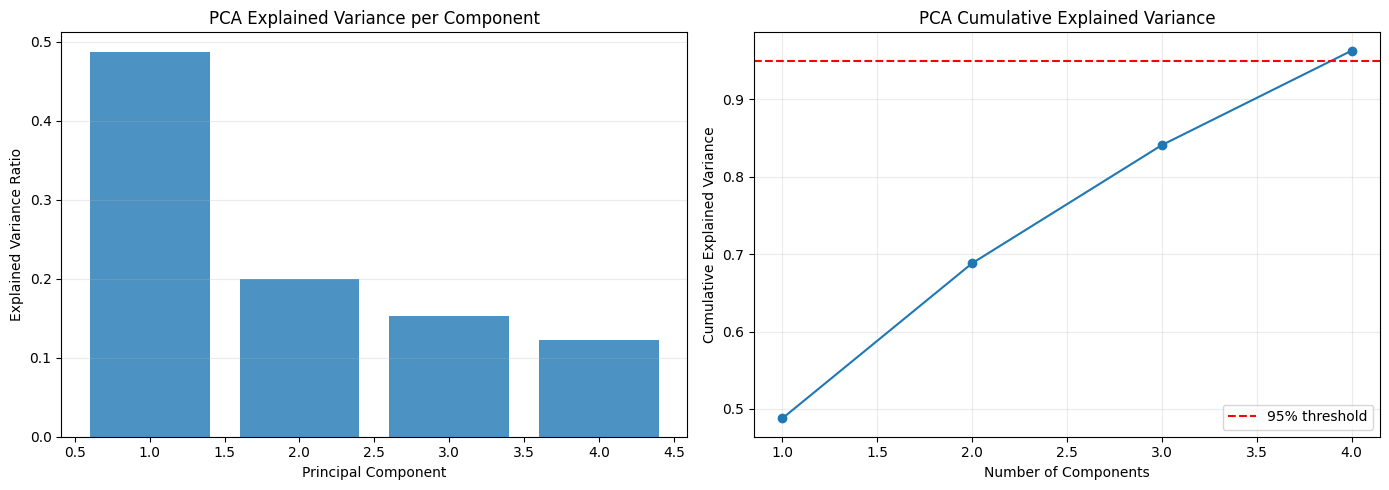

[PCA] 2D plot sampled: 12,000 / 2,733,771


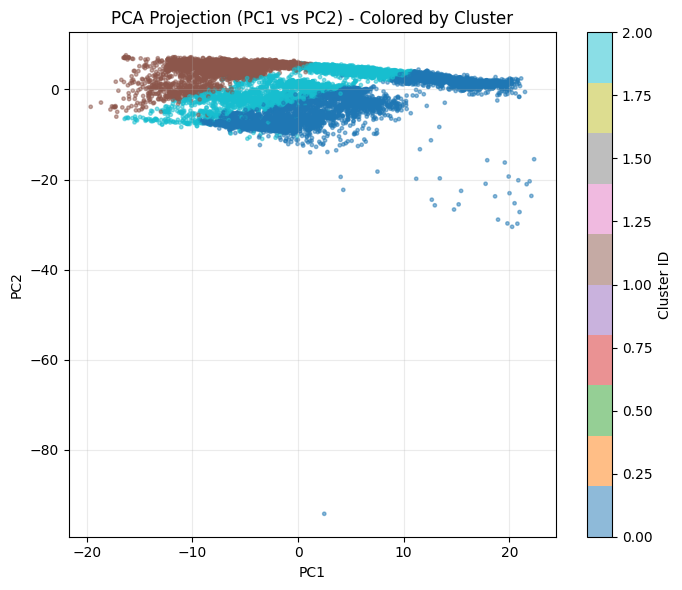

[PCA] 3D PCA plot disabled to avoid kernel restarts.


In [137]:
# Step 3: PCA on temporal sensor statistics.
sensor_stat_cols_all = _collect_sensor_stat_cols(
    sensor_names=sensor_raw_cols,
    sensor_stat_mapping=sensor_stat_map,
    train_clean_df=train_clean,
    test_ctx_df=test_ctx
)

X_train_pca_df, X_test_pca_df, pca, scaler = _fit_scaler_pca(
    train_clean_df=train_clean,
    test_ctx_df=test_ctx,
    sensor_stat_cols=sensor_stat_cols_all,
    seed=SEED
)

# PCA metrics.
explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)
pca_report = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_ratio))],
    "explained_ratio": explained_ratio,
    "cumulative_ratio": cum_explained
})
print("[PCA] Explained variance report (head):")
display(pca_report.head(15))
print(f"[PCA] Components kept: {len(explained_ratio)}")
print(f"[PCA] Total explained variance: {cum_explained[-1]:.4f}")

# Visualization 1: explained variance and cumulative variance.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pc_idx = np.arange(1, len(explained_ratio) + 1)

axes[0].bar(pc_idx, explained_ratio, alpha=0.8)
axes[0].set_title("PCA Explained Variance per Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].grid(alpha=0.25, axis="y")

axes[1].plot(pc_idx, cum_explained, marker="o")
axes[1].axhline(0.95, color="r", linestyle="--", label="95% threshold")
axes[1].set_title("PCA Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Visualization 2: lightweight 2D PCA projection (3D disabled for stability).
PCA_PLOT_MAX_POINTS = 12000

if X_train_pca_df.shape[1] >= 2:
    if len(X_train_pca_df) > PCA_PLOT_MAX_POINTS:
        idx = np.random.default_rng(SEED).choice(len(X_train_pca_df), size=PCA_PLOT_MAX_POINTS, replace=False)
        plot_df = X_train_pca_df.iloc[idx].reset_index(drop=True)
        plot_cluster = train_clean.iloc[idx]["cluster_id"].values
        print(f"[PCA] 2D plot sampled: {PCA_PLOT_MAX_POINTS:,} / {len(X_train_pca_df):,}")
    else:
        plot_df = X_train_pca_df
        plot_cluster = train_clean["cluster_id"].values

    plt.figure(figsize=(7, 6))
    plt.scatter(
        plot_df["PC1"],
        plot_df["PC2"],
        c=plot_cluster,
        cmap="tab10",
        s=6,
        alpha=0.5
    )
    plt.title("PCA Projection (PC1 vs PC2) - Colored by Cluster")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(label="Cluster ID")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

print("[PCA] 3D PCA plot disabled to avoid kernel restarts.")

## 4.4 Retraining Best Baseline Model on Cleaned + Reduced Features

In [138]:
def _build_optimized_model(model_name, seed, input_steps):
    """Create optimized model based on the best baseline type."""
    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=700,
            learning_rate=0.04,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=seed,
            n_jobs=-1
        )

    if model_name == "LightGBM":
        try:
            from lightgbm import LGBMRegressor
        except ImportError as exc:
            raise ImportError(
                "LightGBM is not installed. Please install with: pip install lightgbm"
            ) from exc

        return LGBMRegressor(
            n_estimators=700,
            learning_rate=0.04,
            max_depth=-1,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            random_state=seed,
            n_jobs=-1
        )

    if model_name == "CatBoost":
        try:
            from catboost import CatBoostRegressor
        except ImportError as exc:
            raise ImportError(
                "CatBoost is not installed. Please install with: pip install catboost"
            ) from exc

        return CatBoostRegressor(
            iterations=700,
            learning_rate=0.04,
            depth=6,
            loss_function="RMSE",
            random_seed=seed,
            verbose=False,
            allow_writing_files=False
        )

    if model_name == "RandomForest":
        from sklearn.ensemble import RandomForestRegressor
        return RandomForestRegressor(
            n_estimators=280,
            max_depth=16,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1
        )

    if model_name == "Ridge":
        from sklearn.linear_model import Ridge
        return Ridge(alpha=0.8)

    raise ValueError(f"Unsupported model_name: {model_name}")

In [139]:
# Step 4: Retrain with optimized feature set.
from sklearn.model_selection import train_test_split

X_train_opt, X_test_opt = _build_optimized_matrices(
    X_train_pca_df_local=X_train_pca_df,
    X_test_pca_df_local=X_test_pca_df,
    train_clean_df=train_clean,
    test_ctx_df=test_ctx,
    w_columns=w_cols
)

y_train_opt = train_clean[rul_col].reset_index(drop=True)
y_test_opt = test_ctx[rul_col].reset_index(drop=True)

if "best_baseline_name" not in globals():
    raise NameError("best_baseline_name is missing. Run Section 3.3 baseline training first.")

# Internal validation split from training set only (avoid test leakage).
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_opt,
    y_train_opt,
    test_size=0.15,
    random_state=SEED
)

opt_model = _build_optimized_model(
    model_name=best_baseline_name,
    seed=SEED,
    input_steps=X_train_opt.shape[1]
)
print(f"Training optimized model from best baseline type: {best_baseline_name}...")

opt_model, resumed_opt = _resume_model_from_latest("optimized", best_baseline_name, opt_model)
if resumed_opt and not _is_deep_model(best_baseline_name):
    print(f"[Train] optimized {best_baseline_name}: resumed and skipped refit")
else:
    _ = _fit_model_by_name(
        model_name=best_baseline_name,
        model=opt_model,
        X_train=X_train_sub,
        y_train=y_train_sub,
        X_val=X_val_sub,
        y_val=y_val_sub,
        progress_label=f"optimized {best_baseline_name}"
    )

opt_val_pred = _predict_model_by_name(best_baseline_name, opt_model, X_val_sub)
opt_val_rmse = np.sqrt(mean_squared_error(y_val_sub, opt_val_pred))
opt_val_r2 = r2_score(y_val_sub, opt_val_pred)

_save_model_checkpoint(
    stage="optimized",
    model_name=best_baseline_name,
    model=opt_model,
    metrics={
        "val_rmse": float(opt_val_rmse),
        "val_r2": float(opt_val_r2)
    },
    metric_name=CHECKPOINT_METRIC_NAME,
    metric_mode=CHECKPOINT_METRIC_MODE
)

print("Running inference on optimized test features...")
opt_pred = _predict_model_by_name(best_baseline_name, opt_model, X_test_opt)

rmse_opt = np.sqrt(mean_squared_error(y_test_opt, opt_pred))
r2_opt = r2_score(y_test_opt, opt_pred)

print("\n=== Baseline vs Optimized Comparison ===")
print(f"Baseline  -> RMSE: {rmse_base:.4f}, R2: {r2_base:.4f}")
print(f"Optimized -> RMSE: {rmse_opt:.4f}, R2: {r2_opt:.4f}")
print(f"Delta RMSE (baseline - optimized): {rmse_base - rmse_opt:.4f}")
print(f"Delta R2 (optimized - baseline):   {r2_opt - r2_base:.4f}")
_zip_all_checkpoints()

Training optimized model from best baseline type: Ridge...
[Checkpoint] Loaded full model for Ridge from /kaggle/working/train_checkpoints_20260407_102034/optimized/ridge.joblib
[Train] optimized Ridge: resumed and skipped refit
[Checkpoint] New best (optimized) -> Ridge | val_rmse=21.958484
[Checkpoint] Saved Ridge (optimized) -> /kaggle/working/train_checkpoints_20260407_102839/optimized/ridge.joblib
Running inference on optimized test features...

=== Baseline vs Optimized Comparison ===
Baseline  -> RMSE: 3.8480, R2: 0.9799
Optimized -> RMSE: 20.8124, R2: 0.4125
Delta RMSE (baseline - optimized): -16.9644
Delta R2 (optimized - baseline):   -0.5674
[Checkpoint] Zipped all checkpoints -> /kaggle/working/train_checkpoints_20260407_102839.zip


'/kaggle/working/train_checkpoints_20260407_102839.zip'

[Viz] Rendering training result diagnostics before SHAP...
[Viz] Diagnostics sampled: 12,000 / 836,831


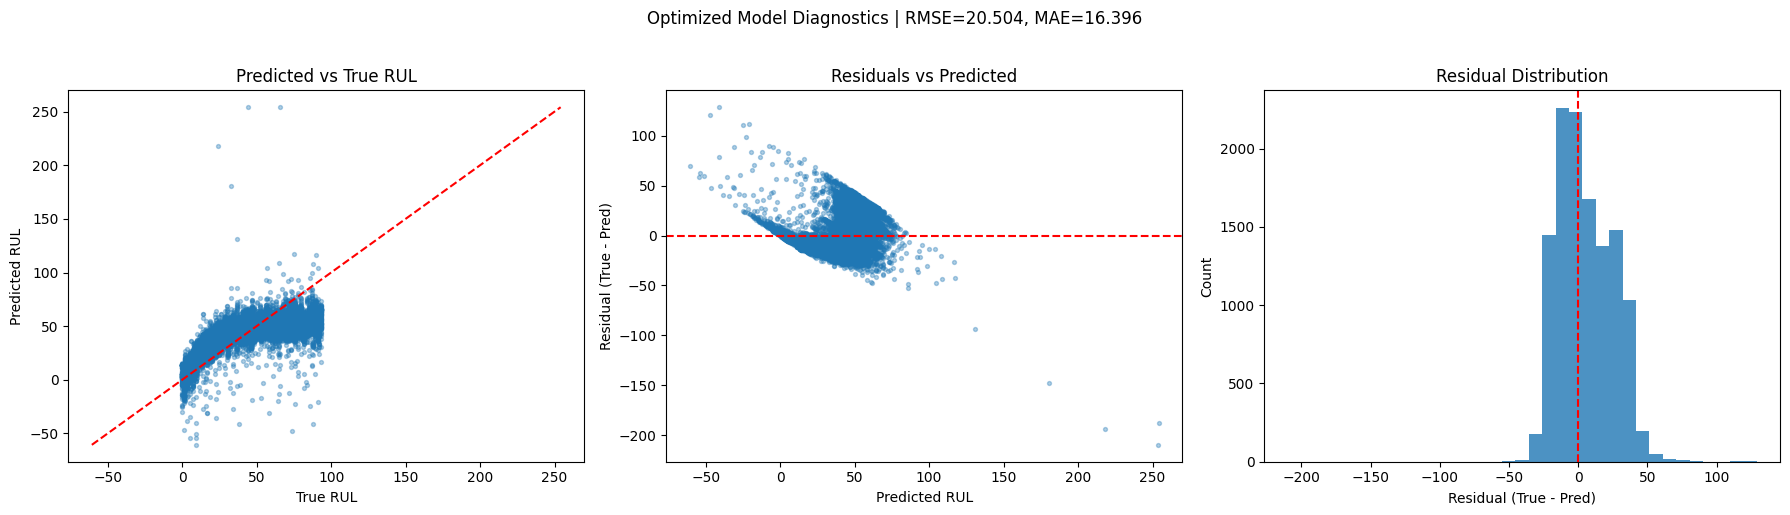

In [140]:
def _plot_training_results(y_true, y_pred, max_points=15000):
    """Visualize prediction quality before SHAP interpretation (memory-safe)."""
    y_true_arr = np.asarray(y_true, dtype=np.float32)
    y_pred_arr = np.asarray(y_pred, dtype=np.float32)

    n_all = len(y_true_arr)
    if n_all > max_points:
        idx = np.random.default_rng(SEED).choice(n_all, size=max_points, replace=False)
        y_true_arr = y_true_arr[idx]
        y_pred_arr = y_pred_arr[idx]
        print(f"[Viz] Diagnostics sampled: {max_points:,} / {n_all:,}")

    residuals = y_true_arr - y_pred_arr

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals ** 2))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Calibration view: ideal points lie on y=x.
    lim_min = float(min(y_true_arr.min(), y_pred_arr.min()))
    lim_max = float(max(y_true_arr.max(), y_pred_arr.max()))
    axes[0].scatter(y_true_arr, y_pred_arr, s=8, alpha=0.35)
    axes[0].plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5)
    axes[0].set_title("Predicted vs True RUL")
    axes[0].set_xlabel("True RUL")
    axes[0].set_ylabel("Predicted RUL")

    # 2) Error structure view.
    axes[1].scatter(y_pred_arr, residuals, s=8, alpha=0.35)
    axes[1].axhline(0, color="r", linestyle="--", linewidth=1.5)
    axes[1].set_title("Residuals vs Predicted")
    axes[1].set_xlabel("Predicted RUL")
    axes[1].set_ylabel("Residual (True - Pred)")

    # 3) Error distribution view.
    axes[2].hist(residuals, bins=35, alpha=0.8)
    axes[2].axvline(0, color="r", linestyle="--", linewidth=1.5)
    axes[2].set_title("Residual Distribution")
    axes[2].set_xlabel("Residual (True - Pred)")
    axes[2].set_ylabel("Count")

    plt.suptitle(f"Optimized Model Diagnostics | RMSE={rmse:.3f}, MAE={mae:.3f}", y=1.02)
    plt.tight_layout()
    plt.show()


print("[Viz] Rendering training result diagnostics before SHAP...")
_plot_training_results(y_test_opt, opt_pred, max_points=12000)

## 5. Explainable AI with SHAP


In [141]:
SHAP_GLOBAL_MAX_SAMPLES = 350
SHAP_BACKGROUND_MAX_SAMPLES = 32
SHAP_USE_APPROX_SUMMARY_BAR = True
SHAP_ENABLE_FORCE_PLOT = False

def _render_global_shap(explainer, X_test_df, max_samples=SHAP_GLOBAL_MAX_SAMPLES):
    """Global SHAP summary on a small sampled subset (lightweight mode)."""
    if "best_baseline_name" in globals() and best_baseline_name in {"Ridge"}:
        max_samples = min(max_samples, 600)

    n = min(max_samples, len(X_test_df))
    idx = np.random.choice(len(X_test_df), size=n, replace=False)
    X_summary = X_test_df.iloc[idx].copy()

    print(f"[SHAP-Global] Computing SHAP values on {len(X_summary)} samples...")
    shap_values = explainer(X_summary)

    if SHAP_USE_APPROX_SUMMARY_BAR:
        # Faster than beeswarm for large feature spaces.
        mean_abs = np.abs(shap_values.values).mean(axis=0)
        top_k = min(20, len(mean_abs))
        order = np.argsort(mean_abs)[::-1][:top_k]
        feat_names = X_summary.columns.to_numpy()[order]
        feat_scores = mean_abs[order]

        plt.figure(figsize=(10, 6))
        plt.barh(np.arange(top_k), feat_scores[::-1], alpha=0.85)
        plt.yticks(np.arange(top_k), feat_names[::-1])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Global Importance (Top Features)")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values.values, X_summary, show=False)
        plt.title("SHAP Summary Plot (Global Interpretation)")
        plt.tight_layout()
        plt.show()

    return idx, shap_values


def _render_local_shap(explainer, model, model_name, X_test_df, y_test_series, near_failure_threshold=30):
    """Local SHAP waterfall (+ optional force plot) on one near-failure sample."""
    near_idx = np.where(y_test_series.values < near_failure_threshold)[0]
    local_i = int(near_idx[0]) if len(near_idx) > 0 else int(np.argmin(y_test_series.values))

    x_local = X_test_df.iloc[[local_i]]
    pred_local = float(_predict_model_by_name(model_name, model, x_local)[0])
    true_local = float(y_test_series.iloc[local_i])
    local_exp = explainer(x_local)

    print(f"[SHAP-Local] Selected index {local_i} | True RUL={true_local:.2f} | Pred RUL={pred_local:.2f}")
    print("[SHAP-Local] Rendering waterfall plot...")
    shap.plots.waterfall(local_exp[0], max_display=15)

    if SHAP_ENABLE_FORCE_PLOT:
        try:
            shap.initjs()
            force_obj = shap.plots.force(
                local_exp[0].base_values,
                local_exp[0].values,
                x_local.iloc[0],
                matplotlib=False
            )
            display(force_obj)
        except Exception as exc:
            print(f"[SHAP-Local] Force plot skipped due to environment limitation: {exc}")
    else:
        print("[SHAP-Local] Force plot disabled in lightweight mode.")

    return local_i, pred_local, true_local


def _plot_pca_back_mapping(pca_model, pca_feature_cols, raw_sensor_cols, top_n_sensors=15, max_pc=8):
    """Back-map PCA loadings to original physical sensors."""
    if pca_model is None or not hasattr(pca_model, "components_"):
        raise ValueError("PCA model is missing or has no components_.")

    comp = np.asarray(pca_model.components_)
    pc_names = [f"PC{i+1}" for i in range(comp.shape[0])]
    loading_df = pd.DataFrame(comp, index=pc_names, columns=pca_feature_cols)

    # Aggregate absolute loading from engineered stat features back to raw sensors.
    agg = {}
    for sensor_name in raw_sensor_cols:
        matched_cols = [c for c in pca_feature_cols if c.startswith(f"{sensor_name}_")]
        if len(matched_cols) == 0:
            continue
        agg[sensor_name] = loading_df[matched_cols].abs().mean(axis=1)

    if len(agg) == 0:
        raise ValueError("Cannot back-map PCA to raw sensors because no matching engineered columns were found.")

    sensor_pc_df = pd.DataFrame(agg).T
    sensor_pc_df.columns = pc_names

    weights = np.asarray(pca_model.explained_variance_ratio_)
    weighted_score = sensor_pc_df.mul(weights, axis=1).sum(axis=1)
    ranked = weighted_score.sort_values(ascending=False)
    top_sensors = ranked.head(top_n_sensors).index.tolist()

    pc_to_plot = pc_names[:min(max_pc, len(pc_names))]
    plot_df = sensor_pc_df.loc[top_sensors, pc_to_plot]

    print("[PCA Back-mapping] Top sensors by weighted loading contribution:")
    display(ranked.head(top_n_sensors).rename("weighted_contribution").to_frame())

    plt.figure(figsize=(1.2 * len(pc_to_plot) + 4, 0.45 * len(top_sensors) + 3))
    sns.heatmap(plot_df, cmap="YlOrRd", annot=False)
    plt.title("PCA Back-mapping: Sensor Contribution to Principal Components")
    plt.xlabel("Principal Components")
    plt.ylabel("Raw Sensors")
    plt.tight_layout()
    plt.show()

    return sensor_pc_df, ranked


def _infer_regime_labels_from_centers(centers_dataframe):
    """Heuristic mapping from cluster center stats to Takeoff/Cruise/Landing labels."""
    cluster_ids = centers_dataframe.index.tolist()
    if len(cluster_ids) != 3:
        return {cid: f"Regime {int(cid)}" for cid in cluster_ids}

    col_map = {c.lower(): c for c in centers_dataframe.columns}

    def _find_col(*keys):
        for k in keys:
            for c_l, c in col_map.items():
                if k in c_l:
                    return c
        return None

    alt_col = _find_col("alt")
    mach_col = _find_col("mach")
    tra_col = _find_col("tra", "throttle")

    labels = {cid: f"Regime {int(cid)}" for cid in cluster_ids}

    if alt_col is None:
        return labels

    cruise_id = centers_dataframe[alt_col].idxmax()
    remain = [cid for cid in cluster_ids if cid != cruise_id]

    if len(remain) == 2:
        if tra_col is not None:
            takeoff_id = centers_dataframe.loc[remain, tra_col].idxmax()
            landing_id = remain[0] if remain[1] == takeoff_id else remain[1]
        elif mach_col is not None:
            takeoff_id = centers_dataframe.loc[remain, mach_col].idxmax()
            landing_id = remain[0] if remain[1] == takeoff_id else remain[1]
        else:
            takeoff_id, landing_id = remain[0], remain[1]

        labels = {
            takeoff_id: "Cat canh",
            cruise_id: "Bay bang",
            landing_id: "Ha canh"
        }

    return labels


def _predict_for_shap_any_model(x):
    """Prediction wrapper so SHAP can call all model types with 2D arrays."""
    if isinstance(x, pd.DataFrame):
        x_df = x.copy()
    else:
        arr = np.asarray(x, dtype=np.float32)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        x_df = pd.DataFrame(arr, columns=X_test_opt.columns)
    return _predict_model_by_name(best_baseline_name, opt_model, x_df)


if "opt_model" not in globals():
    raise NameError("opt_model is missing. Run Section 4 first.")
if "X_test_opt" not in globals() or "y_test_opt" not in globals():
    raise NameError("X_test_opt or y_test_opt is missing. Run Section 4 first.")
if "pca" not in globals() or "sensor_stat_cols_all" not in globals():
    raise NameError("pca or sensor_stat_cols_all is missing. Run PCA step in Section 4 first.")
if "test_ctx" not in globals():
    raise NameError("test_ctx is missing. Run regime assignment step in Section 4 first.")

print("[Section 5] Building SHAP explainer (lightweight)...")
if best_baseline_name in {"XGBoost", "LightGBM", "CatBoost", "RandomForest"}:
    explainer = shap.TreeExplainer(opt_model)
else:
    bg_size = min(SHAP_BACKGROUND_MAX_SAMPLES, len(X_test_opt))
    background = X_test_opt.sample(n=bg_size, random_state=SEED)
    explainer = shap.Explainer(_predict_for_shap_any_model, background, algorithm="permutation")

[Section 5] Building SHAP explainer (lightweight)...


In [142]:
def _regime_based_analysis(
    y_true,
    y_pred,
    cluster_ids,
    sampled_idx_for_shap=None,
    sampled_shap_values=None,
    regime_labels=None
):
    """Compute RMSE and mean(|SHAP|) by flight regime cluster."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)
    cluster_arr = np.asarray(cluster_ids)

    if not (len(y_true_arr) == len(y_pred_arr) == len(cluster_arr)):
        raise ValueError("y_true, y_pred, and cluster_ids must have the same length.")

    regime_labels = regime_labels or {cid: f"Regime {int(cid)}" for cid in np.unique(cluster_arr)}

    rmse_rows = []
    for cid in np.unique(cluster_arr):
        mask = cluster_arr == cid
        rmse_c = np.sqrt(mean_squared_error(y_true_arr[mask], y_pred_arr[mask]))
        rmse_rows.append({
            "cluster_id": int(cid),
            "regime": regime_labels.get(cid, f"Regime {int(cid)}"),
            "n_samples": int(mask.sum()),
            "rmse": float(rmse_c)
        })

    rmse_df = pd.DataFrame(rmse_rows).sort_values("cluster_id").reset_index(drop=True)
    print("[Regime] RMSE by cluster/regime:")
    display(rmse_df)

    plt.figure(figsize=(8, 4.5))
    plt.bar(rmse_df["regime"], rmse_df["rmse"], alpha=0.85)
    plt.title("Regime-based RMSE")
    plt.xlabel("Regime")
    plt.ylabel("RMSE")
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

    shap_cluster_df = None
    if sampled_idx_for_shap is not None and sampled_shap_values is not None:
        sample_clusters = cluster_arr[np.asarray(sampled_idx_for_shap)]
        shap_abs_mean_sample = np.abs(sampled_shap_values.values).mean(axis=1)

        rows = []
        for cid in np.unique(sample_clusters):
            m = sample_clusters == cid
            rows.append({
                "cluster_id": int(cid),
                "regime": regime_labels.get(cid, f"Regime {int(cid)}"),
                "n_shap_samples": int(m.sum()),
                "mean_abs_shap": float(shap_abs_mean_sample[m].mean())
            })
        shap_cluster_df = pd.DataFrame(rows).sort_values("cluster_id").reset_index(drop=True)

        print("[Regime] Mean(|SHAP|) by cluster/regime:")
        display(shap_cluster_df)

        plt.figure(figsize=(8, 4.5))
        plt.bar(shap_cluster_df["regime"], shap_cluster_df["mean_abs_shap"], alpha=0.85)
        plt.title("Regime-based Mean(|SHAP|)")
        plt.xlabel("Regime")
        plt.ylabel("Mean(|SHAP|)")
        plt.grid(alpha=0.25, axis="y")
        plt.tight_layout()
        plt.show()

    return rmse_df, shap_cluster_df


def _residual_analysis(y_true, y_pred):
    """Residual analysis: prediction vs actual + residual distribution."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)
    residuals = y_true_arr - y_pred_arr

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Prediction vs Actual (requested).
    axes[0].scatter(y_true_arr, y_pred_arr, s=10, alpha=0.35)
    lim_min = float(min(y_true_arr.min(), y_pred_arr.min()))
    lim_max = float(max(y_true_arr.max(), y_pred_arr.max()))
    axes[0].plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5)
    axes[0].set_title("Prediction vs Actual")
    axes[0].set_xlabel("Actual RUL")
    axes[0].set_ylabel("Predicted RUL")
    axes[0].grid(alpha=0.25)

    axes[1].hist(residuals, bins=40, alpha=0.85)
    axes[1].axvline(0, color="r", linestyle="--", linewidth=1.5)
    axes[1].set_title("Residual Distribution")
    axes[1].set_xlabel("Residual (Actual - Predicted)")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    return residuals


def _predict_for_shap_any_model(x):
    """Prediction wrapper so SHAP can call all model types with 2D arrays."""
    if isinstance(x, pd.DataFrame):
        x_df = x.copy()
    else:
        arr = np.asarray(x, dtype=np.float32)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        x_df = pd.DataFrame(arr, columns=X_test_opt.columns)
    return _predict_model_by_name(best_baseline_name, opt_model, x_df)


if "opt_model" not in globals():
    raise NameError("opt_model is missing. Run Section 4 first.")
if "X_test_opt" not in globals() or "y_test_opt" not in globals():
    raise NameError("X_test_opt or y_test_opt is missing. Run Section 4 first.")
if "pca" not in globals() or "sensor_stat_cols_all" not in globals():
    raise NameError("pca or sensor_stat_cols_all is missing. Run PCA step in Section 4 first.")
if "test_ctx" not in globals():
    raise NameError("test_ctx is missing. Run regime assignment step in Section 4 first.")

print("[Section 5] Building SHAP explainer...")
if best_baseline_name in {"XGBoost", "LightGBM", "CatBoost", "RandomForest"}:
    explainer = shap.TreeExplainer(opt_model)
else:
    bg_size = min(64, len(X_test_opt))
    background = X_test_opt.sample(n=bg_size, random_state=SEED)
    explainer = shap.Explainer(_predict_for_shap_any_model, background, algorithm="permutation")

[Section 5] Building SHAP explainer...


### 5.1 Global Interpretation - SHAP Summary Plot

[SHAP-Global] Computing SHAP values on 350 samples...


PermutationExplainer explainer: 351it [00:11,  9.02it/s]                         


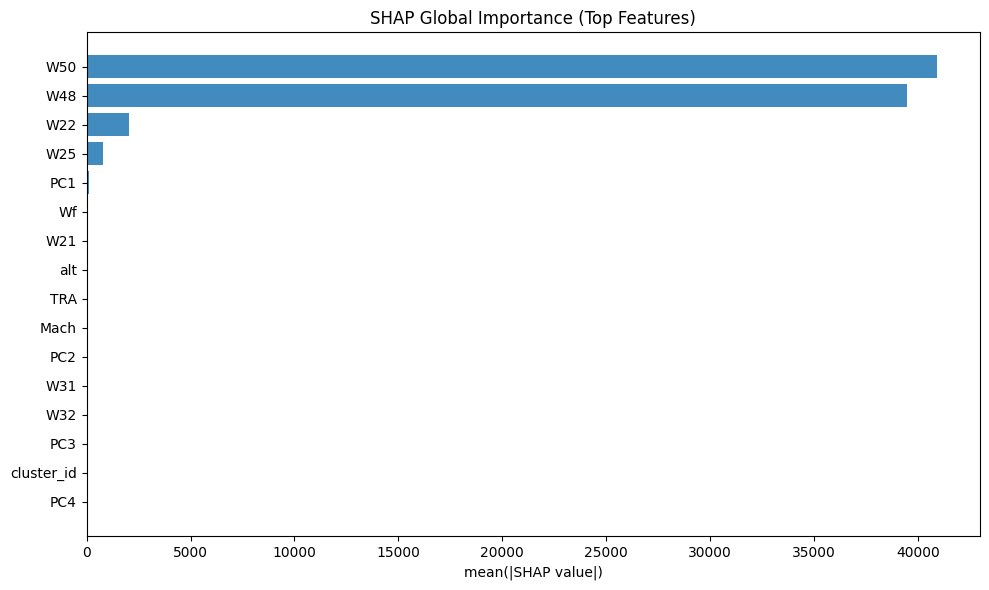

In [143]:
sample_idx, sampled_shap_values = _render_global_shap(
    explainer=explainer,
    X_test_df=X_test_opt,
    max_samples=SHAP_GLOBAL_MAX_SAMPLES
)

### 5.2 Local Interpretation - SHAP Waterfall/Force Plot

[SHAP-Local] Selected index 570814 | True RUL=29.00 | Pred RUL=24.96
[SHAP-Local] Rendering waterfall plot...


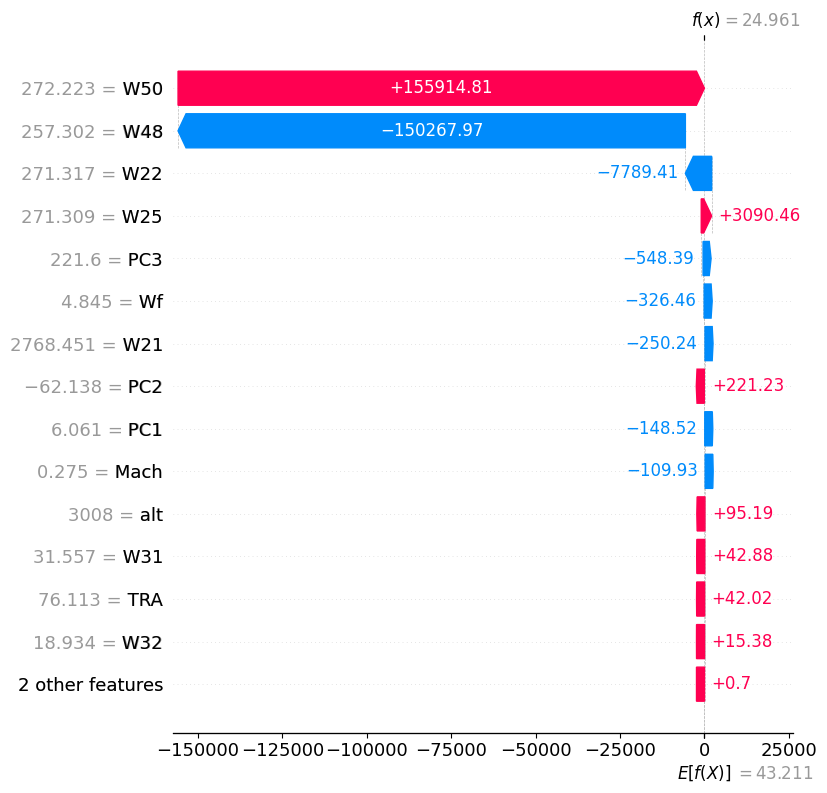

[SHAP-Local] Force plot disabled in lightweight mode.


In [144]:
local_idx, local_pred, local_true = _render_local_shap(
    explainer=explainer,
    model=opt_model,
    model_name=best_baseline_name,
    X_test_df=X_test_opt,
    y_test_series=y_test_opt,
    near_failure_threshold=30
)

### 5.3 PCA Back-mapping to Physical Sensors

[PCA Back-mapping] Top sensors by weighted loading contribution:


,weighted_contribution
P50,0.079154
P21,0.078550
P15,0.078550
T48,0.076415
Nc,0.076392
T40,0.076341
T30,0.076296
P24,0.075358
P2,0.072848
Nf,0.071296


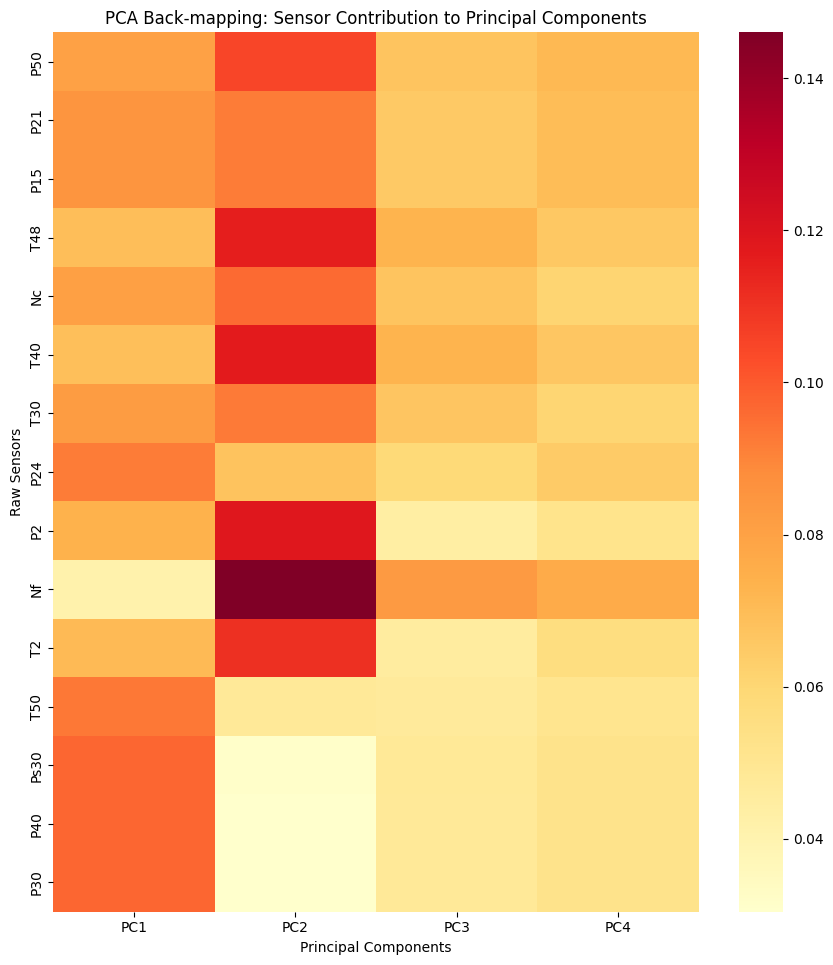

In [145]:
sensor_pc_matrix, sensor_rank = _plot_pca_back_mapping(
    pca_model=pca,
    pca_feature_cols=sensor_stat_cols_all,
    raw_sensor_cols=sensor_raw_cols,
    top_n_sensors=15,
    max_pc=8
)

### 5.4 Regime-based Analysis (Cluster-wise)

[Regime] RMSE by cluster/regime:


,cluster_id,regime,n_samples,rmse
0,0,Ha canh,292260,21.607447
1,1,Bay bang,232273,20.211800
2,2,Cat canh,312298,20.491920


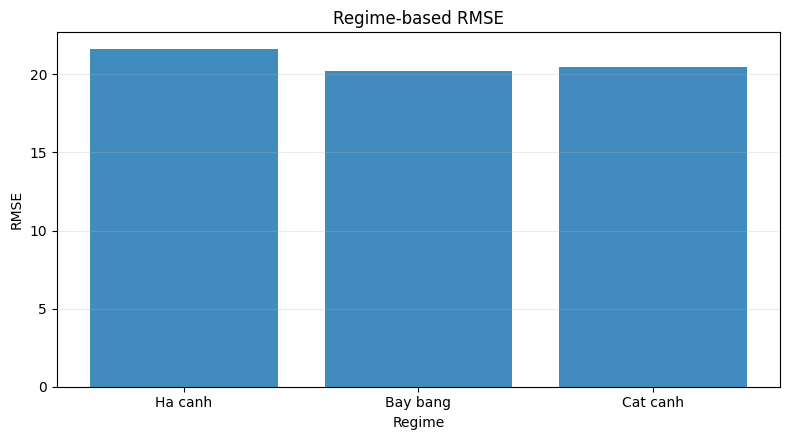

[Regime] Mean(|SHAP|) by cluster/regime:


,cluster_id,regime,n_shap_samples,mean_abs_shap
0,0,Ha canh,123,5520.224201
1,1,Bay bang,95,5682.610065
2,2,Cat canh,132,4640.676621


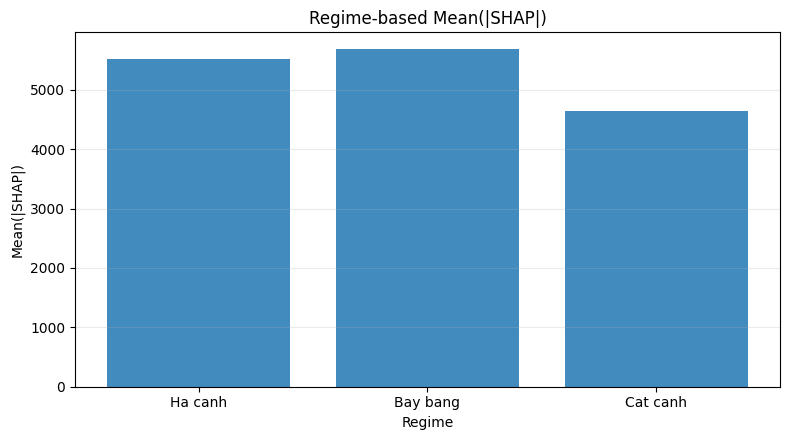

In [146]:
cluster_series = test_ctx["cluster_id"].reset_index(drop=True)
if "centers_df" in globals():
    _centers_local = centers_df.copy()
    _centers_local.index = [
        int(str(i).replace("cluster_", "")) if isinstance(i, str) else int(i)
        for i in _centers_local.index
    ]
    regime_label_map = _infer_regime_labels_from_centers(_centers_local)
else:
    regime_label_map = {cid: f"Regime {int(cid)}" for cid in np.unique(cluster_series.values)}

rmse_by_regime, shap_by_regime = _regime_based_analysis(
    y_true=y_test_opt.values,
    y_pred=opt_pred,
    cluster_ids=cluster_series.values,
    sampled_idx_for_shap=sample_idx,
    sampled_shap_values=sampled_shap_values,
    regime_labels=regime_label_map
)

### 5.5 Residual Analysis - Prediction vs Actual

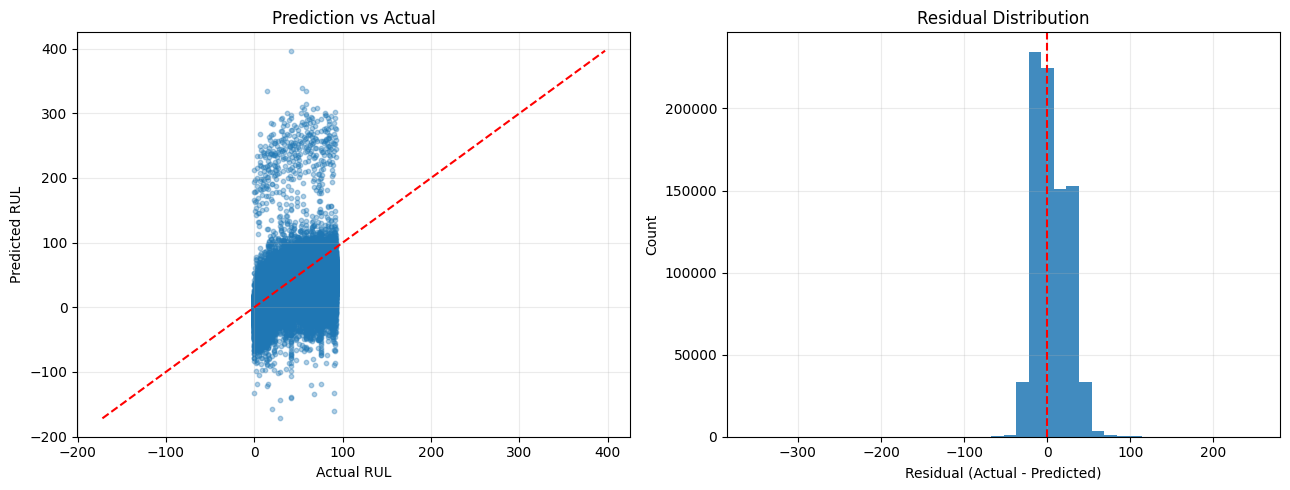

In [147]:
residuals_opt = _residual_analysis(y_test_opt.values, opt_pred)

=== Final Summary Metrics ===


,stage,model,rmse,r2,delta_rmse_vs_baseline,delta_r2_vs_baseline
0,Baseline (best),Ridge,3.847953,0.979917,0.00000,0.000000
1,Optimized,Ridge,20.812392,0.412480,16.96444,-0.567437


[Dashboard] Scatter sampled: 15,000 / 836,831


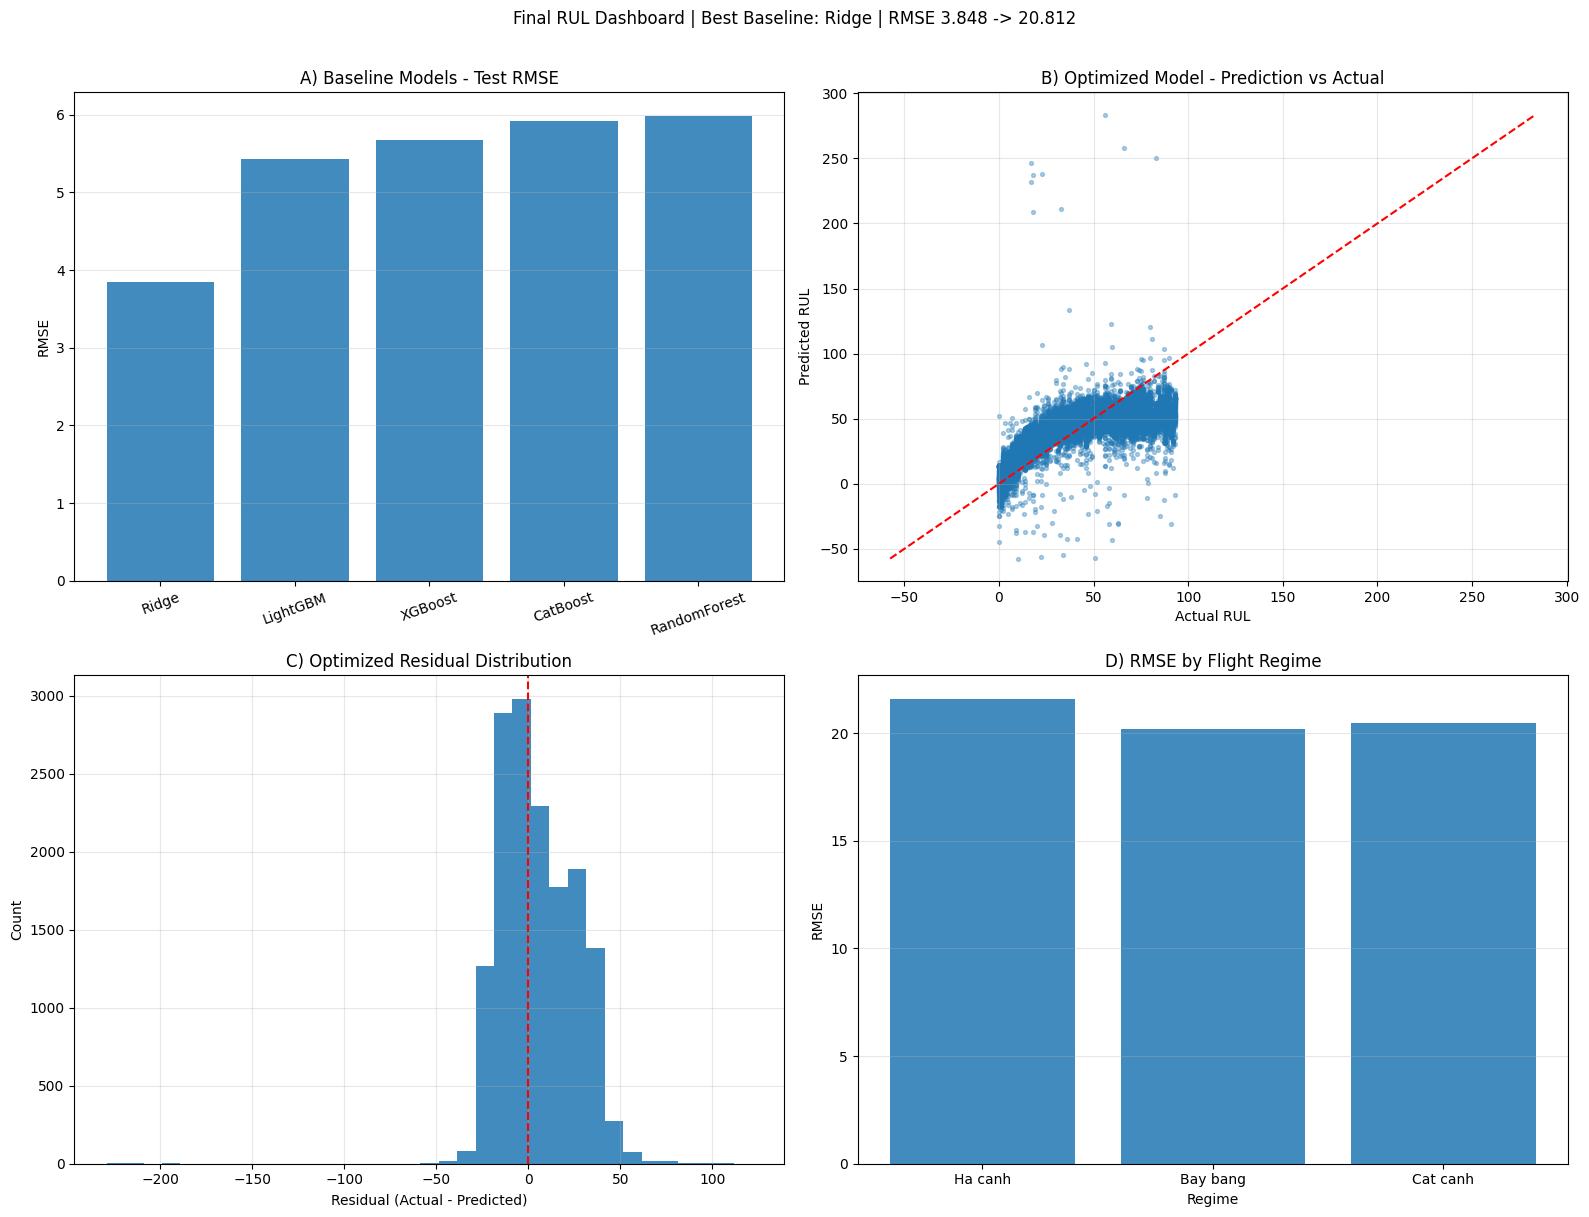

In [148]:
# Final mini dashboard: key metrics + 4 most important plots in one place (lightweight).
required_vars = [
    "baseline_compare_df", "best_baseline_name",
    "y_test_opt", "opt_pred",
    "rmse_base", "r2_base", "rmse_opt", "r2_opt"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing required variables for dashboard: {missing}. "
        "Run Sections 3-5 first."
    )

DASHBOARD_SCATTER_MAX_POINTS = 15000

# 1) Compact metrics table for final reporting.
summary_rows = [
    {"stage": "Baseline (best)", "model": best_baseline_name, "rmse": float(rmse_base), "r2": float(r2_base)},
    {"stage": "Optimized", "model": best_baseline_name, "rmse": float(rmse_opt), "r2": float(r2_opt)},
]
summary_df = pd.DataFrame(summary_rows)
summary_df["delta_rmse_vs_baseline"] = summary_df["rmse"] - float(rmse_base)
summary_df["delta_r2_vs_baseline"] = summary_df["r2"] - float(r2_base)

print("=== Final Summary Metrics ===")
display(summary_df)

# 2) Build 2x2 dashboard figure.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot A: baseline model comparison (test RMSE).
plot_df = baseline_compare_df.sort_values("test_rmse", ascending=True).reset_index(drop=True)
xpos = np.arange(len(plot_df))
axes[0, 0].bar(xpos, plot_df["test_rmse"], alpha=0.85)
axes[0, 0].set_xticks(xpos)
axes[0, 0].set_xticklabels(plot_df["model"], rotation=20)
axes[0, 0].set_title("A) Baseline Models - Test RMSE")
axes[0, 0].set_ylabel("RMSE")
axes[0, 0].grid(alpha=0.3, axis="y")

# Plot B/C: sampled prediction-residual diagnostics.
y_true_all = np.asarray(y_test_opt, dtype=np.float32)
y_hat_all = np.asarray(opt_pred, dtype=np.float32)

n_all = len(y_true_all)
if n_all > DASHBOARD_SCATTER_MAX_POINTS:
    idx = np.random.default_rng(SEED).choice(n_all, size=DASHBOARD_SCATTER_MAX_POINTS, replace=False)
    y_true = y_true_all[idx]
    y_hat = y_hat_all[idx]
    print(f"[Dashboard] Scatter sampled: {DASHBOARD_SCATTER_MAX_POINTS:,} / {n_all:,}")
else:
    y_true = y_true_all
    y_hat = y_hat_all

vmin = float(min(y_true.min(), y_hat.min()))
vmax = float(max(y_true.max(), y_hat.max()))
axes[0, 1].scatter(y_true, y_hat, s=8, alpha=0.35)
axes[0, 1].plot([vmin, vmax], [vmin, vmax], "r--", linewidth=1.5)
axes[0, 1].set_title("B) Optimized Model - Prediction vs Actual")
axes[0, 1].set_xlabel("Actual RUL")
axes[0, 1].set_ylabel("Predicted RUL")
axes[0, 1].grid(alpha=0.3)

residuals = y_true - y_hat
axes[1, 0].hist(residuals, bins=35, alpha=0.85)
axes[1, 0].axvline(0, color="r", linestyle="--", linewidth=1.5)
axes[1, 0].set_title("C) Optimized Residual Distribution")
axes[1, 0].set_xlabel("Residual (Actual - Predicted)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(alpha=0.3)

# Plot D: regime RMSE if available; otherwise optimized vs baseline bars.
if "rmse_by_regime" in globals() and rmse_by_regime is not None and len(rmse_by_regime) > 0:
    axes[1, 1].bar(rmse_by_regime["regime"], rmse_by_regime["rmse"], alpha=0.85)
    axes[1, 1].set_title("D) RMSE by Flight Regime")
    axes[1, 1].set_xlabel("Regime")
    axes[1, 1].set_ylabel("RMSE")
    axes[1, 1].grid(alpha=0.3, axis="y")
else:
    labels = ["Baseline", "Optimized"]
    vals = [float(rmse_base), float(rmse_opt)]
    axes[1, 1].bar(labels, vals, alpha=0.85)
    axes[1, 1].set_title("D) Baseline vs Optimized RMSE")
    axes[1, 1].set_ylabel("RMSE")
    axes[1, 1].grid(alpha=0.3, axis="y")

fig.suptitle(
    f"Final RUL Dashboard | Best Baseline: {best_baseline_name} | "
    f"RMSE {rmse_base:.3f} -> {rmse_opt:.3f}",
    y=1.01
)
plt.tight_layout()
plt.show()